# Southend Pier -- Stage 3: Multi-Resolution Meteorological Fusion (PyTorch)

Stage 3 adds meteorological covariates (pressure, wind, rainfall, discharge) on top of stage 2's encoder-decoder-attention architecture. Full mechanism and rationale: [`stage3_architecture.md`](stage3_architecture.md).

- **Multi-resolution fusion**: pressure/wind (hourly), rainfall/discharge (daily), and tide (10-minutely) each get their own `Encoder` + `BatchedAttention` branch, fused at the bridge and in decoder attention.
- **Decoder redesign**: the decoder runs over a 34-point padded UTide sequence and reads out 30 daily horizons (vs. stage 2's 7 sparse points), fixing an edge-horizon asymmetry in stage 2's decoder. A tide-only ablation (`TidalSeq2SeqTideOnly`, s.8e) uses the same decoder with the meteo/river branches removed.
- **SHAP interpretability** and a **training-data-volume ablation**, mirroring stage 2 s.13.3.

No calendar-time plots in this notebook -- every chart is error-vs-forecast-distance or SHAP attribution.

**Data**: Southend Pier gauge (`10_SOUTHEND_chatter_and_stuck_patched.csv`) plus ERA5 pressure/wind and NRFA rainfall/discharge at Kingston, from `meteo_data/consolidated/`.

**Split**: train 2004-2017, validation 2018-2020, test 2021-2024.

## 1. Setup

In [42]:
# Colab doesn't preinstall `utide` or `shap` -- check for each and install
# whatever's missing, the same pattern stage 2 uses for utide alone, just
# generalised to loop over every non-preinstalled package this notebook needs.
import importlib
import sys

for pkg, pip_name in [("utide", "UTide"), ("shap", "shap")]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"'{pkg}' not found -- installing '{pip_name}'...")
        get_ipython().system(f"{{sys.executable}} -m pip install -q {pip_name}")
        importlib.import_module(pkg)
    else:
        print(f"'{pkg}' already available.")


'utide' already available.
'shap' already available.


In [43]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import utide
import shap


In [44]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported:  {torch.cuda.is_bf16_supported()}")
else:
    print("No GPU detected -- this notebook is sized for a Colab T4 (Runtime > Change runtime "
          "type > T4 GPU). It will still run on CPU, just much slower -- the meteo/river "
          "branches and the wider 30-horizon decoder add real compute on top of stage 2.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU:             NVIDIA A100-SXM4-80GB
BF16 supported:  True


In [45]:
SEED = 42

# --- reused verbatim from stage 2 ---
LOOKBACK = 96          # 16h of 10-minute steps, tide-branch encoder window
TRAIN_STRIDE = 3        # subsample training windows every 3rd step (30 min) to cut epoch time
BATCH_SIZE = 512        # same as stage 2; reduce if this OOMs on your GPU (more branches + a
                         # wider decoder sequence use more memory per sample than stage 2 did)
EPOCHS = 60              # full-budget epoch cap, used only for the *final* training run in s.9b
                         # (post-search) and for every scenario in s.12 -- not for search trials
PATIENCE = 10
LR = 1e-3                # stage 2's own fixed learning rate -- kept only as the centre of the
                         # random-search range below; neither model is actually trained at this
                         # value directly (s.9a searches around it, s.9b trains at the winner)
TRAIN_END = '2018-01-01'
VAL_END = '2021-01-01'

# --- new: random hyperparameter search (s.9a), run independently for each of the two main
# models before their full-budget training run. Short, cheap trials (reduced epoch cap and
# patience) act as a proxy for the full run -- picks a winning (lr, weight_decay, batch_size)
# combo per model, which then gets one full-budget retrain at EPOCHS/PATIENCE above.
LR_SEARCH_MIN, LR_SEARCH_MAX = 3e-4, 3e-3   # one order of magnitude either side of stage 2's 1e-3
WEIGHT_DECAY_CHOICES = [0.0, 1e-5, 1e-4]
BATCH_SIZE_CHOICES = [256, 512, 1024]
N_SEARCH_TRIALS = 6
SEARCH_EPOCHS = 12
SEARCH_PATIENCE = 4

ENC_HIDDEN_SIZE = 64     # tide-branch encoder (unchanged from stage 2)
ENC_NUM_LAYERS = 1
DEC_HIDDEN_SIZE = 64
DEC_NUM_LAYERS = 1
ATTN_DIM_TIDE = 64

SITE_LAT = 51.5145
STEP = pd.Timedelta('10min')
M2_STEPS = 74.5          # ~M2 semi-diurnal tidal period in 10-minute steps (unused directly
                          # here, kept for parity with stage 2 -- see stage2_architecture.md s.4)

# --- new: meteo (hourly) and river (daily) branches ---
METEO_HIDDEN_SIZE = 64
METEO_LOOKBACK_HOURS = 120   # 5 days -- EDA/meteo_eda.ipynb s.2.3: pressure ACF < 0.2 by ~121h
ATTN_DIM_METEO = 64

RIVER_HIDDEN_SIZE = 32       # smaller: EDA found ~no correlation between rainfall/discharge
                              # and the Southend residual at any lag -- see markdown s.3 below
RIVER_LOOKBACK_DAYS = 30     # comfortably longer than the ~2-day rainfall->discharge catchment
                              # lag the EDA found; not derived from a residual-correlation peak,
                              # since the EDA didn't find one for this gauge
ATTN_DIM_RIVER = 32

# --- new: extended horizon set. The 7 original horizons are unchanged and stay the ones
# reported against UTide; the daily extension out to 30 days is what the decoder redesign
# trains against -- see stage3_architecture.md s.3 for why this is possible (and s.6 for the
# one honest caveat about how far the *skill* is expected to hold).
STEPS_PER_DAY = 144  # 24h * 6 (10-min steps per hour)
HEADLINE_HORIZONS = {'10min': 1, '1h': 6, '6h': 36, '24h': 144, '48h': 288, '72h': 432, '168h': 1008}
EXTENDED_DAY_NUMS = list(range(8, 31))  # 8..30 inclusive -> 23 entries
EXTENDED_HORIZONS = {f'{d}d': d * STEPS_PER_DAY for d in EXTENDED_DAY_NUMS}
HORIZONS = {**HEADLINE_HORIZONS, **EXTENDED_HORIZONS}
HORIZON_NAMES = list(HORIZONS.keys())
HORIZON_STEPS = list(HORIZONS.values())
N_HORIZONS = len(HORIZON_STEPS)
HEADLINE_NAMES = HORIZON_NAMES[:len(HEADLINE_HORIZONS)]  # the stage-2-comparable 7, for reporting

# decoder's own input sequence: a leading "now" point, the 30 real (trained) horizons, and a
# small trailing margin past 30d -- purely so neither 10min nor 30d sits at the literal edge
# of the BiLSTM's sequence (see stage3_architecture.md s.4 for the full reasoning).
TRAIL_PAD_DAYS = [31, 32, 33]
TRAIL_PAD_STEPS = [d * STEPS_PER_DAY for d in TRAIL_PAD_DAYS]
DECODER_SEQ_STEPS = [0] + HORIZON_STEPS + TRAIL_PAD_STEPS   # 34 points
DECODER_SEQ_LEN = len(DECODER_SEQ_STEPS)
TARGET_SLICE_IN_DECODER = slice(1, 1 + N_HORIZONS)          # which of the 34 are the 30 real horizons

UTIDE_EXT_DAYS = 35          # buffer past the last gauge row, must exceed the 33d trailing pad
DAILY_GRID_BUFFER_DAYS = 40  # buffer for the daily meteo grid, same reason

# --- optional, off-by-default training lever (see markdown in s.9) ---
USE_HORIZON_LOSS_WEIGHTING = False


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
torch.backends.cudnn.benchmark = True

print(f"{N_HORIZONS} trained horizons: {HORIZON_NAMES}")
print(f"headline (stage-2-comparable) horizons: {HEADLINE_NAMES}")
print(f"decoder sequence length: {DECODER_SEQ_LEN} (1 leading pad + {N_HORIZONS} horizons + {len(TRAIL_PAD_STEPS)} trailing pad)")


30 trained horizons: ['10min', '1h', '6h', '24h', '48h', '72h', '168h', '8d', '9d', '10d', '11d', '12d', '13d', '14d', '15d', '16d', '17d', '18d', '19d', '20d', '21d', '22d', '23d', '24d', '25d', '26d', '27d', '28d', '29d', '30d']
headline (stage-2-comparable) horizons: ['10min', '1h', '6h', '24h', '48h', '72h', '168h']
decoder sequence length: 34 (1 leading pad + 30 horizons + 3 trailing pad)


## 2. Load data (Google Drive)

In [46]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tidal_analysis_and_prediction'
    DATA_PATH = os.path.join(BASE_DIR, '10_SOUTHEND_chatter_and_stuck_patched.csv')
    METEO_DIR = os.path.join(BASE_DIR, 'meteo_data', 'consolidated')
    OUTPUT_DIR = os.path.join(BASE_DIR, 'stage3_outputs')
else:
    DATA_PATH = '../../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv'
    METEO_DIR = '../../3_Cleaned/meteo'
    OUTPUT_DIR = '../../outputs/stage3_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
assert os.path.exists(DATA_PATH), f"Can't find gauge data at {DATA_PATH} -- update the path above."
assert os.path.isdir(METEO_DIR), f"Can't find meteo data at {METEO_DIR} -- update the path above."

if IN_COLAB:
    sys.path.insert(0, BASE_DIR)  # plot_config.py uploaded to the same Drive folder as the data
else:
    sys.path.insert(0, '../../utils')  # plot_config.py lives in the repo's utils/ folder
from plot_config import SERIES_COLOURS, save_fig, set_report_dir
set_report_dir(os.path.join(BASE_DIR, 'report_images') if IN_COLAB else '../../report_images')

LOAD_FROM_CHECKPOINT = True  # skip training/search and load saved weights from OUTPUT_DIR if present

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
usecols = ['DateTime', 'Observed_ODN', 'is_chatter_flagged', 'is_stuck_flagged', 'is_imputed']
df = pd.read_csv(DATA_PATH, usecols=usecols, parse_dates=['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['is_flagged'] = df['is_chatter_flagged'] | df['is_stuck_flagged'] | df['is_imputed']

gap_mask = df['DateTime'].diff() > STEP
print(f"{len(df):,} rows, {df.DateTime.min()} to {df.DateTime.max()}")
print(f"{gap_mask.sum()} gaps > 10min ({gap_mask.sum() + 1} contiguous segments)")
print(f"Flagged (chatter/stuck/imputed) points: {df['is_flagged'].sum():,} ({100 * df['is_flagged'].mean():.3f}%)")
df.head()


1,103,956 rows, 2004-01-01 00:00:00 to 2024-12-31 23:50:00
90 gaps > 10min (91 contiguous segments)
Flagged (chatter/stuck/imputed) points: 9,975 (0.904%)


,DateTime,is_imputed,Observed_ODN,is_chatter_flagged,is_stuck_flagged,is_flagged
0,2004-01-01 00:00:00,False,-1.819,False,False,False
1,2004-01-01 00:10:00,False,-1.855,False,False,False
2,2004-01-01 00:20:00,False,-1.874,False,False,False
3,2004-01-01 00:30:00,False,-1.895,False,False,False
4,2004-01-01 00:40:00,False,-1.904,False,False,False


In [48]:
pressure = pd.read_csv(os.path.join(METEO_DIR, "pressure_all_gauges.csv"), parse_dates=["valid_time"])
pressure = pressure.rename(columns={"Southend Pier_msl": "msl_pa"})

wind = pd.read_csv(os.path.join(METEO_DIR, "wind_all_gauges.csv"), parse_dates=["valid_time"])
wind = wind.rename(columns={"Southend Pier_u10": "u10", "Southend Pier_v10": "v10"})

rainfall = pd.read_csv(os.path.join(METEO_DIR, "rainfall_kingston_catchment.csv"), parse_dates=["date"])
discharge = pd.read_csv(os.path.join(METEO_DIR, "river_discharge_kingston.csv"), parse_dates=["date"])

print(f"pressure: {len(pressure):,} rows, {pressure.valid_time.min()} to {pressure.valid_time.max()}")
print(f"wind:     {len(wind):,} rows, {wind.valid_time.min()} to {wind.valid_time.max()}")
print(f"rainfall: {len(rainfall):,} rows, {rainfall.date.min()} to {rainfall.date.max()}  <- ends before discharge, see s.3 below")
print(f"discharge:{len(discharge):,} rows, {discharge.date.min()} to {discharge.date.max()}")


pressure: 184,104 rows, 2004-01-01 00:00:00 to 2024-12-31 23:00:00
wind:     184,104 rows, 2004-01-01 00:00:00 to 2024-12-31 23:00:00
rainfall: 7,305 rows, 2004-01-01 00:00:00 to 2023-12-31 00:00:00  <- ends before discharge, see s.3 below
discharge:7,579 rows, 2004-01-01 00:00:00 to 2024-09-30 00:00:00


## 3. Meteorological preprocessing

Pressure/wind are hourly, complete across 2004-2024. Rainfall stops 2023-12-31, discharge stops 2024-09-30 (both gaps fall inside the test split); missing days filled with train-split month-of-year climatology, alongside an availability flag. Wind kept as u/v components (v10 was the strongest single covariate in the EDA).

In [49]:
pressure["msl_hpa"] = pressure["msl_pa"] / 100.0

hourly = pressure[["valid_time", "msl_hpa"]].merge(wind[["valid_time", "u10", "v10"]], on="valid_time", how="inner")
hourly = hourly.sort_values("valid_time").reset_index(drop=True)
assert len(hourly) == len(pressure) == len(wind), "pressure/wind hourly grids don't match 1:1"
hourly_diffs = hourly["valid_time"].diff().dropna()
assert (hourly_diffs == pd.Timedelta("1h")).all(), "hourly grid has gaps -- unexpected per EDA"

HOURLY_START = hourly["valid_time"].iloc[0].to_numpy()
hourly_pressure_arr = hourly["msl_hpa"].to_numpy(dtype=np.float32)
hourly_u10_arr = hourly["u10"].to_numpy(dtype=np.float32)
hourly_v10_arr = hourly["v10"].to_numpy(dtype=np.float32)
print(f"hourly meteo grid verified complete: {len(hourly):,} rows, {hourly['valid_time'].min()} to {hourly['valid_time'].max()}")


hourly meteo grid verified complete: 184,104 rows, 2004-01-01 00:00:00 to 2024-12-31 23:00:00


In [50]:
daily_start_ts = df["DateTime"].min().normalize()
daily_end_ts = df["DateTime"].max().normalize() + pd.Timedelta(days=DAILY_GRID_BUFFER_DAYS)
full_daily_index = pd.date_range(daily_start_ts, daily_end_ts, freq="D")

rain_s = rainfall.set_index("date")["value"].reindex(full_daily_index)
disc_s = discharge.set_index("date")["value"].reindex(full_daily_index)
rain_avail_s = rain_s.notna().astype(np.float32)
disc_avail_s = disc_s.notna().astype(np.float32)

# train-split month-of-year climatology -- fit on train dates only
train_date_mask = full_daily_index < pd.Timestamp(TRAIN_END)
rain_clim = rain_s[train_date_mask].groupby(full_daily_index[train_date_mask].month).mean()
disc_clim = disc_s[train_date_mask].groupby(full_daily_index[train_date_mask].month).mean()
assert rain_clim.isna().sum() == 0 and disc_clim.isna().sum() == 0, "train split has gaps?! shouldn't per EDA"

month_of_day = pd.Series(full_daily_index.month, index=full_daily_index)
rain_filled_s = rain_s.fillna(month_of_day.map(rain_clim))
disc_filled_s = disc_s.fillna(month_of_day.map(disc_clim))
assert rain_filled_s.isna().sum() == 0 and disc_filled_s.isna().sum() == 0, "climatology fill left NaNs"

DAILY_START = full_daily_index[0].to_numpy()
daily_rain_arr = rain_filled_s.to_numpy(dtype=np.float32)
daily_disc_arr = disc_filled_s.to_numpy(dtype=np.float32)
daily_rain_avail_arr = rain_avail_s.to_numpy(dtype=np.float32)
daily_disc_avail_arr = disc_avail_s.to_numpy(dtype=np.float32)

n_rain_filled, n_disc_filled = int((rain_avail_s == 0).sum()), int((disc_avail_s == 0).sum())
print(f"rainfall:  {n_rain_filled} synthetic (climatology-filled) days"
      + (f", {rain_s[rain_s.isna()].index.min().date()} to {rain_s[rain_s.isna()].index.max().date()}" if n_rain_filled else ""))
print(f"discharge: {n_disc_filled} synthetic (climatology-filled) days"
      + (f", {disc_s[disc_s.isna()].index.min().date()} to {disc_s[disc_s.isna()].index.max().date()}" if n_disc_filled else ""))
print("(the tail of this range is padding beyond the real gauge record, for the decoder's trailing "
      "context points -- not itself a data gap; the genuine gaps are the 2024 rainfall/discharge cutoffs.)")


rainfall:  406 synthetic (climatology-filled) days, 2024-01-01 to 2025-02-09
discharge: 132 synthetic (climatology-filled) days, 2024-10-01 to 2025-02-09
(the tail of this range is padding beyond the real gauge record, for the decoder's trailing context points -- not itself a data gap; the genuine gaps are the 2024 rainfall/discharge cutoffs.)


## 4. UTide harmonic reconstruction

Same fit as stage 2 (train split only), reconstructed out to 33 days past the last gauge row so the decoder's trailing pad points are always computable.

In [51]:
train_mask_full = df['DateTime'] < TRAIN_END
fit_series = df.loc[train_mask_full, 'Observed_ODN'].copy()
fit_series[df.loc[train_mask_full, 'is_flagged']] = np.nan

coef = utide.solve(
    df.loc[train_mask_full, 'DateTime'], fit_series,
    lat=SITE_LAT, method='ols', conf_int='none',
)
print(f"UTide fit on {train_mask_full.sum():,} training rows "
      f"({(~np.isnan(fit_series)).sum():,} after excluding flagged points).")


solve: matrix prep ... solution ... done.
UTide fit on 735,760 training rows (725,912 after excluding flagged points).


In [52]:
utide_index = pd.date_range(df['DateTime'].min(), df['DateTime'].max() + pd.Timedelta(days=UTIDE_EXT_DAYS), freq='10min')
recon = utide.reconstruct(utide_index, coef, min_SNR=0, min_PE=0, verbose=False)
utide_recon_full = np.asarray(recon['h'], dtype=np.float32)
UTIDE_START = utide_index[0].to_numpy()
print(f"reconstructed {len(utide_index):,} steps, {utide_index.min()} to {utide_index.max()} "
      f"({UTIDE_EXT_DAYS}d past the last gauge row)")


reconstructed 1,109,664 steps, 2004-01-01 00:00:00 to 2025-02-04 23:50:00 (35d past the last gauge row)


## 5. Chronological train / validation / test split

Same boundaries as stage 1/2.

In [53]:
train_df = df[df['DateTime'] < TRAIN_END].reset_index(drop=True)
val_df = df[(df['DateTime'] >= TRAIN_END) & (df['DateTime'] < VAL_END)].reset_index(drop=True)
test_df = df[df['DateTime'] >= VAL_END].reset_index(drop=True)

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{split_name:5s}: {len(split):>8,} rows  [{split.DateTime.min()} -> {split.DateTime.max()}]  "
          f"flagged={100 * split['is_flagged'].mean():.3f}%")


train:  735,760 rows  [2004-01-01 00:00:00 -> 2017-12-31 23:50:00]  flagged=1.338%
val  :  157,824 rows  [2018-01-01 00:00:00 -> 2020-12-31 23:50:00]  flagged=0.038%
test :  210,372 rows  [2021-01-01 00:00:00 -> 2024-12-31 23:50:00]  flagged=0.032%


## 6. Multi-resolution windowing

Each anchor carries: the `LOOKBACK` tide history, the last 120h of `[pressure_hpa, u10, v10]`, the last 30 days of `[rainfall, discharge, rainfall_available, discharge_available]`, and the 34-point UTide decoder sequence (0h pad, 30 real horizons, 31-33d trailing pad). Anchors need a full history and a full 30-day target within their own segment.

In [54]:
def gather_window(full_arr, end_idx, L):
    # window of length L ending at (inclusive) index end_idx, gathered for every row at once
    starts_ = end_idx - (L - 1)
    sw = np.lib.stride_tricks.sliding_window_view(full_arr, L)
    return sw[starts_]


def build_windows_stage3(sub_df, lookback, horizon_steps, utide_full=None, utide_start=None):
    # utide_full/utide_start default to the main-run globals; the training-data-volume
    # ablation (s.12) passes its own re-fit reconstruction explicitly instead, so each
    # reduced-training scenario sees the UTide input a model trained only on that
    # window would actually have.
    utide_full = utide_recon_full if utide_full is None else utide_full
    utide_start = UTIDE_START if utide_start is None else utide_start

    sub_df = sub_df.reset_index(drop=True)
    is_gap = sub_df['DateTime'].diff() > STEP
    seg_id = is_gap.cumsum().to_numpy()

    values = sub_df['Observed_ODN'].to_numpy(dtype=np.float32)
    flagged = sub_df['is_flagged'].to_numpy()
    times = sub_df['DateTime'].to_numpy()

    max_h = max(horizon_steps)
    horizon_arr = np.array(horizon_steps)

    X_list, Y_list, Flag_list, Time_list = [], [], [], []
    for seg in np.unique(seg_id):
        idx = np.where(seg_id == seg)[0]
        n = len(idx)
        if n < lookback + max_h:
            continue

        seg_values = values[idx]
        seg_flag = flagged[idx]
        seg_time = times[idx]

        n_windows = n - lookback - max_h + 1
        enc_windows = np.lib.stride_tricks.sliding_window_view(seg_values, lookback)[:n_windows]
        starts = np.arange(n_windows)
        # window `s` covers positions s..s+lookback-1; horizon k's target sits k steps after
        # the last encoder value (k=1 -> next step) -- unchanged from stage 2's build_windows_multi
        target_positions = starts[:, None] + (lookback - 1) + horizon_arr[None, :]

        X_list.append(enc_windows)
        Y_list.append(seg_values[target_positions])
        Flag_list.append(seg_flag[target_positions])
        Time_list.append(seg_time[target_positions])

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    Flag = np.concatenate(Flag_list, axis=0)
    Time = np.concatenate(Time_list, axis=0)          # (N, n_horizons) -- target time per horizon
    anchor_time = Time[:, 0] - np.timedelta64(horizon_steps[0] * 10, 'm')

    # --- meteo/river/UTide: gap-free grids, gathered by absolute wall-clock offset,
    # independent of the tide gauge's own segment structure ---
    anchor_utide_idx = ((anchor_time - utide_start) / np.timedelta64(10, 'm')).astype(np.int64)
    dec_offsets = np.array(DECODER_SEQ_STEPS)
    assert anchor_utide_idx.max() + dec_offsets.max() < len(utide_full), "utide extension buffer too small!"
    Ydec_dense = utide_full[anchor_utide_idx[:, None] + dec_offsets[None, :]]

    anchor_hourly_idx = np.floor((anchor_time - HOURLY_START) / np.timedelta64(1, 'h')).astype(np.int64)
    anchor_daily_idx = np.floor(
        (anchor_time.astype('datetime64[D]') - DAILY_START.astype('datetime64[D]')) / np.timedelta64(1, 'D')
    ).astype(np.int64)

    valid = (anchor_hourly_idx - (METEO_LOOKBACK_HOURS - 1) >= 0) & (anchor_daily_idx - (RIVER_LOOKBACK_DAYS - 1) >= 0)

    X_meteo = np.stack([
        gather_window(hourly_pressure_arr, anchor_hourly_idx, METEO_LOOKBACK_HOURS),
        gather_window(hourly_u10_arr, anchor_hourly_idx, METEO_LOOKBACK_HOURS),
        gather_window(hourly_v10_arr, anchor_hourly_idx, METEO_LOOKBACK_HOURS),
    ], axis=-1)

    X_river = np.stack([
        gather_window(daily_rain_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
        gather_window(daily_disc_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
        gather_window(daily_rain_avail_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
        gather_window(daily_disc_avail_arr, anchor_daily_idx, RIVER_LOOKBACK_DAYS),
    ], axis=-1)

    return (X[valid], X_meteo[valid], X_river[valid], Ydec_dense[valid],
            Y[valid], Flag[valid], Time[valid], anchor_time[valid])


In [55]:
X_train, Xm_train, Xr_train, Ydec_train, Y_train, Flag_train, Time_train, Anchor_train = \
    build_windows_stage3(train_df, LOOKBACK, HORIZON_STEPS)
X_train, Xm_train, Xr_train, Ydec_train, Y_train, Flag_train, Time_train, Anchor_train = (
    X_train[::TRAIN_STRIDE], Xm_train[::TRAIN_STRIDE], Xr_train[::TRAIN_STRIDE], Ydec_train[::TRAIN_STRIDE],
    Y_train[::TRAIN_STRIDE], Flag_train[::TRAIN_STRIDE], Time_train[::TRAIN_STRIDE], Anchor_train[::TRAIN_STRIDE],
)

X_val, Xm_val, Xr_val, Ydec_val, Y_val, Flag_val, Time_val, Anchor_val = \
    build_windows_stage3(val_df, LOOKBACK, HORIZON_STEPS)
X_test, Xm_test, Xr_test, Ydec_test, Y_test, Flag_test, Time_test, Anchor_test = \
    build_windows_stage3(test_df, LOOKBACK, HORIZON_STEPS)

print(f"windows -> train: {X_train.shape} (stride {TRAIN_STRIDE}), val: {X_val.shape}, test: {X_test.shape}")
print(f"per-branch shapes (train): tide={X_train.shape} meteo={Xm_train.shape} river={Xr_train.shape} "
      f"decoder-utide={Ydec_train.shape} targets={Y_train.shape}")

# the sparse, stage-2-shaped UTide-standalone comparator is just a slice of the dense sequence
Ydec_targets_train = Ydec_train[:, TARGET_SLICE_IN_DECODER]
Ydec_targets_val = Ydec_val[:, TARGET_SLICE_IN_DECODER]
Ydec_targets_test = Ydec_test[:, TARGET_SLICE_IN_DECODER]
assert Ydec_targets_test.shape[1] == N_HORIZONS


windows -> train: (171336, 96) (stride 3), val: (153409, 96), test: (169821, 96)
per-branch shapes (train): tide=(171336, 96) meteo=(171336, 120, 3) river=(171336, 30, 4) decoder-utide=(171336, 34) targets=(171336, 30)


Self-check confirming the offset arithmetic and availability-mask logic against this run's real data.

In [56]:
# anchor + horizon offset should reproduce each horizon's target time exactly
for j in [0, len(HEADLINE_HORIZONS) - 1, N_HORIZONS - 1]:   # 10min, 168h, 30d
    expected = Anchor_test + np.timedelta64(HORIZON_STEPS[j] * 10, 'm')
    assert np.array_equal(expected, Time_test[:, j]), f"horizon {HORIZON_NAMES[j]} offset mismatch"
print("anchor+horizon offset arithmetic verified for 10min / 168h / 30d")

for name, arr in [("X", X_test), ("X_meteo", Xm_test), ("X_river", Xr_test), ("Ydec", Ydec_test), ("Y", Y_test)]:
    assert not np.isnan(arr).any(), f"{name} has NaNs!"
print("no NaNs in any test-split array")

print(f"\ntest-split flagged target fraction: {Flag_test.mean()*100:.3f}%")
print(f"test-split mean rainfall availability in river-branch lookback: {Xr_test[..., 2].mean()*100:.1f}% "
      f"(<100% only where the 2024 rainfall gap falls inside a window's 30d lookback)")
print(f"test-split mean discharge availability in river-branch lookback: {Xr_test[..., 3].mean()*100:.1f}%")


anchor+horizon offset arithmetic verified for 10min / 168h / 30d
no NaNs in any test-split array

test-split flagged target fraction: 0.033%
test-split mean rainfall availability in river-branch lookback: 78.5% (<100% only where the 2024 rainfall gap falls inside a window's 30d lookback)
test-split mean discharge availability in river-branch lookback: 99.7%


## 7. Scaling

Train-split mean/std for every variable (`Observed_ODN`/`utide_recon` share one scaler). River availability flags left unscaled.

In [57]:
train_mean = float(train_df['Observed_ODN'].mean())
train_std = float(train_df['Observed_ODN'].std())

pressure_mean, pressure_std = float(Xm_train[..., 0].mean()), float(Xm_train[..., 0].std())
u10_mean, u10_std = float(Xm_train[..., 1].mean()), float(Xm_train[..., 1].std())
v10_mean, v10_std = float(Xm_train[..., 2].mean()), float(Xm_train[..., 2].std())
rain_mean, rain_std = float(Xr_train[..., 0].mean()), float(Xr_train[..., 0].std())
disc_mean, disc_std = float(Xr_train[..., 1].mean()), float(Xr_train[..., 1].std())

print(f"tide/utide:  mean={train_mean:.4f} m,  std={train_std:.4f} m")
print(f"pressure:    mean={pressure_mean:.2f} hPa, std={pressure_std:.2f} hPa")
print(f"u10:         mean={u10_mean:.3f} m/s,  std={u10_std:.3f} m/s")
print(f"v10:         mean={v10_mean:.3f} m/s,  std={v10_std:.3f} m/s")
print(f"rainfall:    mean={rain_mean:.3f} mm,  std={rain_std:.3f} mm")
print(f"discharge:   mean={disc_mean:.2f} m3/s, std={disc_std:.2f} m3/s")


def to_tensor(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype, device=device)


def scale_tide(a):
    return (a - train_mean) / train_std


def scale_meteo(xm):
    out = xm.copy()
    out[..., 0] = (out[..., 0] - pressure_mean) / pressure_std
    out[..., 1] = (out[..., 1] - u10_mean) / u10_std
    out[..., 2] = (out[..., 2] - v10_mean) / v10_std
    return out


def scale_river(xr):
    out = xr.copy()
    out[..., 0] = (out[..., 0] - rain_mean) / rain_std
    out[..., 1] = (out[..., 1] - disc_mean) / disc_std
    return out  # availability channels (2,3) left as 0/1, unscaled


X_train_t, Xm_train_t, Xr_train_t = to_tensor(scale_tide(X_train)), to_tensor(scale_meteo(Xm_train)), to_tensor(scale_river(Xr_train))
Ydec_train_t, Y_train_t = to_tensor(scale_tide(Ydec_train)), to_tensor(scale_tide(Y_train))
Flag_train_t = to_tensor(Flag_train, dtype=torch.bool)

X_val_t, Xm_val_t, Xr_val_t = to_tensor(scale_tide(X_val)), to_tensor(scale_meteo(Xm_val)), to_tensor(scale_river(Xr_val))
Ydec_val_t, Y_val_t = to_tensor(scale_tide(Ydec_val)), to_tensor(scale_tide(Y_val))
Flag_val_t = to_tensor(Flag_val, dtype=torch.bool)

X_test_t, Xm_test_t, Xr_test_t = to_tensor(scale_tide(X_test)), to_tensor(scale_meteo(Xm_test)), to_tensor(scale_river(Xr_test))
Ydec_test_t = to_tensor(scale_tide(Ydec_test))


tide/utide:  mean=0.1459 m,  std=1.5730 m
pressure:    mean=1015.11 hPa, std=10.00 hPa
u10:         mean=1.421 m/s,  std=3.777 m/s
v10:         mean=0.834 m/s,  std=3.798 m/s
rainfall:    mean=2.021 mm,  std=3.810 mm
discharge:   mean=51.81 m3/s, std=65.29 m3/s


## 8. Models

`Encoder`/`BatchedAttention` reused from stage 2, instantiated three times (tide/meteo/river). `MultiBranchTidalDecoder` and `TidalSeq2SeqMulti` are new.

### 8a. Encoder (reused verbatim from stage 2)

In [58]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):  # x: (B, T_hist, input_size)
        enc_outputs, (h_n, c_n) = self.lstm(x)
        return enc_outputs, (h_n, c_n)


### 8b. Attention (reused verbatim from stage 2)

In [59]:
class BatchedAttention(nn.Module):
    def __init__(self, dec_dim, enc_dim, attn_dim):
        super().__init__()
        self.dec_proj = nn.Linear(dec_dim, attn_dim)
        self.enc_proj = nn.Linear(enc_dim, attn_dim)

    def forward(self, dec_out, enc_outputs):
        q = self.dec_proj(dec_out)                # (B, H, attn_dim)
        k = self.enc_proj(enc_outputs)             # (B, T_hist, attn_dim)
        scores = torch.bmm(q, k.transpose(1, 2))   # (B, H, T_hist)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, enc_outputs)  # (B, H, enc_dim) -- raw enc_outputs, not k
        return context, weights


### 8c. Decoder -- multi-branch bridge, densified/padded sequence, per-branch attention

1. **Bridge**: `init_h`/`init_c` project from the concatenation of all three branches' final hidden states.
2. **Decoder sequence**: BiLSTM runs over the full 34-point padded UTide sequence, then sliced to the 30 trained horizon positions.
3. **Attention**: one `BatchedAttention` instance per branch, concatenated with `dec_out` before the output head.

In [60]:
class MultiBranchTidalDecoder(nn.Module):
    def __init__(self, dec_hidden_size, dec_num_layers, branch_hidden_sizes, attn_dims,
                 decoder_seq_len, target_slice):
        super().__init__()
        self.hidden_size = dec_hidden_size
        self.num_layers = dec_num_layers
        self.decoder_seq_len = decoder_seq_len
        self.target_slice = target_slice
        bridge_dim = sum(branch_hidden_sizes)  # tide + meteo + river final-hidden concat

        self.lstm = nn.LSTM(1, dec_hidden_size, dec_num_layers, batch_first=True, bidirectional=True)
        self.init_h = nn.Linear(bridge_dim, dec_num_layers * 2 * dec_hidden_size)
        self.init_c = nn.Linear(bridge_dim, dec_num_layers * 2 * dec_hidden_size)

        self.attn_tide = BatchedAttention(2 * dec_hidden_size, branch_hidden_sizes[0], attn_dims[0])
        self.attn_meteo = BatchedAttention(2 * dec_hidden_size, branch_hidden_sizes[1], attn_dims[1])
        self.attn_river = BatchedAttention(2 * dec_hidden_size, branch_hidden_sizes[2], attn_dims[2])

        out_dim = 2 * dec_hidden_size + sum(branch_hidden_sizes)
        self.out = nn.Linear(out_dim, 1)

    def forward(self, utide_dense, enc_tide, final_tide, enc_meteo, final_meteo, enc_river, final_river):
        # final encoder layer only from each branch, matching stage 2's convention
        h_tide, c_tide = final_tide[0][-1], final_tide[1][-1]
        h_meteo, c_meteo = final_meteo[0][-1], final_meteo[1][-1]
        h_river, c_river = final_river[0][-1], final_river[1][-1]

        h_bridge = torch.cat([h_tide, h_meteo, h_river], dim=-1)
        c_bridge = torch.cat([c_tide, c_meteo, c_river], dim=-1)
        B = h_bridge.size(0)

        h0 = self.init_h(h_bridge).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = self.init_c(c_bridge).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()

        dec_out_dense, _ = self.lstm(utide_dense.unsqueeze(-1), (h0, c0))   # (B, 34, 2*hidden)
        dec_out = dec_out_dense[:, self.target_slice, :]                    # (B, 30, 2*hidden)

        context_tide, w_tide = self.attn_tide(dec_out, enc_tide)
        context_meteo, w_meteo = self.attn_meteo(dec_out, enc_meteo)
        context_river, w_river = self.attn_river(dec_out, enc_river)

        combined = torch.cat([dec_out, context_tide, context_meteo, context_river], dim=-1)
        preds = self.out(combined).squeeze(-1)   # (B, 30)
        return preds, (w_tide, w_meteo, w_river)


### 8d. Full model

In [61]:
class TidalSeq2SeqMulti(nn.Module):
    # Stage 3: three encoders (tide/meteo/river) + multi-branch attention + UTide-informed
    # BiLSTM decoder over a densified, padded horizon sequence.

    def __init__(self):
        super().__init__()
        self.encoder_tide = Encoder(1, ENC_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.encoder_meteo = Encoder(3, METEO_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.encoder_river = Encoder(4, RIVER_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.decoder = MultiBranchTidalDecoder(
            DEC_HIDDEN_SIZE, DEC_NUM_LAYERS,
            branch_hidden_sizes=(ENC_HIDDEN_SIZE, METEO_HIDDEN_SIZE, RIVER_HIDDEN_SIZE),
            attn_dims=(ATTN_DIM_TIDE, ATTN_DIM_METEO, ATTN_DIM_RIVER),
            decoder_seq_len=DECODER_SEQ_LEN, target_slice=TARGET_SLICE_IN_DECODER,
        )

    def forward(self, x_tide, x_meteo, x_river, utide_dense):
        enc_tide, final_tide = self.encoder_tide(x_tide.unsqueeze(-1))
        enc_meteo, final_meteo = self.encoder_meteo(x_meteo)
        enc_river, final_river = self.encoder_river(x_river)
        preds, weights = self.decoder(utide_dense, enc_tide, final_tide, enc_meteo, final_meteo, enc_river, final_river)
        return preds, weights


set_seed()
stage3_model = TidalSeq2SeqMulti().to(device)  # provisional instance, just for the count below --
                                                # re-instantiated fresh in s.9b after the hp search
n_params = sum(p.numel() for p in stage3_model.parameters())
print(f"TidalSeq2SeqMulti: {n_params:,} parameters")


TidalSeq2SeqMulti: 145,505 parameters


### 8e. Ablation: tide-only decoder (no meteo/river)

`TideOnlyDecoder` is the single-branch counterpart to `MultiBranchTidalDecoder`: same decoder sequence and horizons, fed only the tide branch. Isolates the meteo/river contribution, the same way stage 2 section 13.1 isolated UTide's contribution. Learning rate/weight decay/batch size are tuned independently for the two models -- see s.9a.

In [62]:
class TideOnlyDecoder(nn.Module):
    def __init__(self, dec_hidden_size, dec_num_layers, tide_hidden_size, attn_dim,
                 decoder_seq_len, target_slice):
        super().__init__()
        self.hidden_size = dec_hidden_size
        self.num_layers = dec_num_layers
        self.decoder_seq_len = decoder_seq_len
        self.target_slice = target_slice

        self.lstm = nn.LSTM(1, dec_hidden_size, dec_num_layers, batch_first=True, bidirectional=True)
        self.init_h = nn.Linear(tide_hidden_size, dec_num_layers * 2 * dec_hidden_size)
        self.init_c = nn.Linear(tide_hidden_size, dec_num_layers * 2 * dec_hidden_size)
        self.attn_tide = BatchedAttention(2 * dec_hidden_size, tide_hidden_size, attn_dim)
        self.out = nn.Linear(2 * dec_hidden_size + tide_hidden_size, 1)

    def forward(self, utide_dense, enc_tide, final_tide):
        h_tide, c_tide = final_tide[0][-1], final_tide[1][-1]
        B = h_tide.size(0)

        h0 = self.init_h(h_tide).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = self.init_c(c_tide).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()

        dec_out_dense, _ = self.lstm(utide_dense.unsqueeze(-1), (h0, c0))
        dec_out = dec_out_dense[:, self.target_slice, :]

        context_tide, w_tide = self.attn_tide(dec_out, enc_tide)
        combined = torch.cat([dec_out, context_tide], dim=-1)
        preds = self.out(combined).squeeze(-1)
        return preds, (w_tide,)


class TidalSeq2SeqTideOnly(nn.Module):
    # Same redesigned decoder (densified sequence, 30 horizons) as TidalSeq2SeqMulti,
    # but no meteo/river branches -- the ablation the user asked to check.

    def __init__(self):
        super().__init__()
        self.encoder_tide = Encoder(1, ENC_HIDDEN_SIZE, ENC_NUM_LAYERS)
        self.decoder = TideOnlyDecoder(
            DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ENC_HIDDEN_SIZE, ATTN_DIM_TIDE,
            decoder_seq_len=DECODER_SEQ_LEN, target_slice=TARGET_SLICE_IN_DECODER,
        )

    def forward(self, x_tide, utide_dense):
        enc_tide, final_tide = self.encoder_tide(x_tide.unsqueeze(-1))
        preds, weights = self.decoder(utide_dense, enc_tide, final_tide)
        return preds, weights


set_seed()
stage3_tideonly_model = TidalSeq2SeqTideOnly().to(device)  # provisional, see note above re: s.9b
n_params_tideonly = sum(p.numel() for p in stage3_tideonly_model.parameters())
print(f"TidalSeq2SeqTideOnly: {n_params_tideonly:,} parameters (vs {n_params:,} for the full multi-branch model)")


TidalSeq2SeqTideOnly: 80,705 parameters (vs 145,505 for the full multi-branch model)


## 9. Training

Masked MSE over all (sample, horizon) pairs, flagged targets excluded. `batch_iter`, `masked_mse`, `train_model`, `compute_metrics` are reused unchanged from stage 2.

Loss stays unweighted across horizons by default (`USE_HORIZON_LOSS_WEIGHTING` in s.1 toggles otherwise).

Each model gets its own random hyperparameter search (s.9a) before a full-budget retrain (s.9b) -- forcing identical hyperparameters onto two different architectures would risk confounding the ablation.

In [63]:
def batch_iter(tensors, batch_size, shuffle):
    n = tensors['X'].shape[0]
    idx = torch.randperm(n, device=tensors['X'].device) if shuffle else torch.arange(n, device=tensors['X'].device)
    for start in range(0, n, batch_size):
        b = idx[start:start + batch_size]
        yield {k: v[b] for k, v in tensors.items()}


HORIZON_WEIGHTS = None
if USE_HORIZON_LOSS_WEIGHTING:
    with torch.no_grad():
        per_horizon_var = Y_train_t.var(dim=0)              # (30,), scaled units
        HORIZON_WEIGHTS = (1.0 / per_horizon_var)
        HORIZON_WEIGHTS = (HORIZON_WEIGHTS / HORIZON_WEIGHTS.mean()).to(device)
    print("Horizon loss weighting ENABLED -- weights:", HORIZON_WEIGHTS.cpu().numpy().round(3))


def masked_mse(pred, true, flag_b):
    sq_err = (pred - true) ** 2
    if HORIZON_WEIGHTS is not None:
        sq_err = sq_err * HORIZON_WEIGHTS
    return sq_err[~flag_b].mean()


def masked_rmse_mae(pred, true, flagged):
    # pred, true, flagged: (N, H) arrays -- returns per-horizon RMSE/MAE with flagged targets excluded.
    rmses, maes = [], []
    for j in range(pred.shape[1]):
        mask = ~flagged[:, j]
        err = pred[mask, j] - true[mask, j]
        rmses.append(float(np.sqrt(np.mean(err ** 2))))
        maes.append(float(np.mean(np.abs(err))))
    return np.array(rmses), np.array(maes)


def train_model(model, predict_fn, train_tensors, val_tensors, epochs, batch_size, lr, patience, label,
                 weight_decay=0.0):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    use_amp = device.type == 'cuda'

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss, n_seen = 0.0, 0
        for batch in batch_iter(train_tensors, batch_size, shuffle=True):
            opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                pred = predict_fn(model, batch)
                loss = masked_mse(pred, batch['Y'], batch['Flag'])
            loss.backward()
            opt.step()
            n_valid = int((~batch['Flag']).sum())
            running_loss += loss.item() * n_valid
            n_seen += n_valid
        train_loss = running_loss / n_seen

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        with torch.no_grad():
            for batch in batch_iter(val_tensors, batch_size, shuffle=False):
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                    pred = predict_fn(model, batch)
                    loss = masked_mse(pred, batch['Y'], batch['Flag'])
                n_valid = int((~batch['Flag']).sum())
                val_loss_sum += loss.item() * n_valid
                n_val += n_valid
        val_loss = val_loss_sum / n_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        sched.step(val_loss)

        improved = val_loss < best_val - 1e-6
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{label}] epoch {epoch + 1:03d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}"
              f"  lr={opt.param_groups[0]['lr']:.1e}{'  *' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"[{label}] early stopping at epoch {epoch + 1} (best val_loss={best_val:.5f})")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def compute_metrics(model, predict_fn, tensors, y_raw, flagged, batch_size=4096):
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * train_std + train_mean
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m


def load_or_train(model, checkpoint_path, train_fn, label):
    # Skip training and load a saved state dict if LOAD_FROM_CHECKPOINT is set and one exists --
    # both model classes take no constructor args (architecture hyperparameters are the fixed
    # globals set in s.1), so re-instantiating is enough to make a saved state dict load cleanly.
    if LOAD_FROM_CHECKPOINT and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        print(f"[{label}] loaded weights from {checkpoint_path}")
        return model, None
    return train_fn(model)


def load_or_search(checkpoint_path, search_fn, label):
    # Skip the random search and reuse the winning (lr, weight_decay, batch_size) already saved
    # in a checkpoint's config, if one exists -- avoids re-running search trials just to get
    # values that are only needed for a from-scratch retrain we're about to skip anyway.
    if LOAD_FROM_CHECKPOINT and os.path.exists(checkpoint_path):
        cfg = torch.load(checkpoint_path, map_location=device)['config']
        best = {'lr': cfg['lr'], 'weight_decay': cfg['weight_decay'], 'batch_size': cfg['batch_size']}
        print(f"[{label}] using search-winning hyperparameters saved in {checkpoint_path}: {best}")
        return best, None
    return search_fn()

In [64]:
train_tensors = {'X': X_train_t, 'Xm': Xm_train_t, 'Xr': Xr_train_t, 'Ydec': Ydec_train_t,
                 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors = {'X': X_val_t, 'Xm': Xm_val_t, 'Xr': Xr_val_t, 'Ydec': Ydec_val_t,
               'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors = {'X': X_test_t, 'Xm': Xm_test_t, 'Xr': Xr_test_t, 'Ydec': Ydec_test_t}
predict_stage3 = lambda model, batch: model(batch['X'], batch['Xm'], batch['Xr'], batch['Ydec'])[0]

# ablation: same underlying tensors, just without the meteo/river branches
train_tensors_tideonly = {'X': X_train_t, 'Ydec': Ydec_train_t, 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors_tideonly = {'X': X_val_t, 'Ydec': Ydec_val_t, 'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors_tideonly = {'X': X_test_t, 'Ydec': Ydec_test_t}
predict_stage3_tideonly = lambda model, batch: model(batch['X'], batch['Ydec'])[0]


### 9a. Random search (learning rate, weight decay, batch size)

`sample_hparams` draws a candidate config; `random_search` runs `N_SEARCH_TRIALS` at a reduced epoch budget. Run independently for each model; results logged to `stage3_lr_search_{multi,tideonly}.csv`.

In [65]:
def sample_hparams(rng):
    log_lr = rng.uniform(np.log(LR_SEARCH_MIN), np.log(LR_SEARCH_MAX))
    return {
        'lr': float(np.exp(log_lr)),
        'weight_decay': float(rng.choice(WEIGHT_DECAY_CHOICES)),
        'batch_size': int(rng.choice(BATCH_SIZE_CHOICES)),
    }


def random_search(model_ctor, predict_fn, train_tensors, val_tensors, label, rng,
                   n_trials=N_SEARCH_TRIALS, epochs=SEARCH_EPOCHS, patience=SEARCH_PATIENCE):
    trial_records = []
    for t in range(n_trials):
        hp = sample_hparams(rng)
        set_seed()  # identical init/batch order across trials -- only hp differs
        model = model_ctor().to(device)
        _, history = train_model(
            model, predict_fn, train_tensors, val_tensors,
            epochs=epochs, batch_size=hp['batch_size'], lr=hp['lr'],
            patience=patience, weight_decay=hp['weight_decay'], label=f'{label}-search{t + 1}',
        )
        best_val = min(history['val_loss'])
        trial_records.append({**hp, 'best_val_loss': best_val})
        print(f"[{label}] trial {t + 1}/{n_trials}: lr={hp['lr']:.2e}  weight_decay={hp['weight_decay']:.0e}"
              f"  batch_size={hp['batch_size']}  -> best_val_loss={best_val:.5f}")

    trials_df = pd.DataFrame(trial_records).sort_values('best_val_loss').reset_index(drop=True)
    best = trials_df.iloc[0].to_dict()
    print(f"[{label}] winner: lr={best['lr']:.2e}  weight_decay={best['weight_decay']:.0e}"
          f"  batch_size={int(best['batch_size'])}  (val_loss={best['best_val_loss']:.5f})")
    return best, trials_df


search_rng = np.random.default_rng(SEED)


In [66]:
checkpoint_path_multi = os.path.join(OUTPUT_DIR, 'stage3_tidal_seq2seq_multi.pt')
best_multi, search_trials_multi = load_or_search(
    checkpoint_path_multi,
    lambda: random_search(TidalSeq2SeqMulti, predict_stage3, train_tensors, val_tensors,
                           label='stage3-multi', rng=search_rng),
    label='stage3-multi',
)
LR_MULTI, WD_MULTI, BATCH_MULTI = best_multi['lr'], best_multi['weight_decay'], int(best_multi['batch_size'])

if search_trials_multi is not None:
    search_trials_multi_path = os.path.join(OUTPUT_DIR, 'stage3_lr_search_multi.csv')
    search_trials_multi.to_csv(search_trials_multi_path, index=False)
    print(f"saved {search_trials_multi_path}")

[stage3-multi] using search-winning hyperparameters saved in /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_multi.pt: {'lr': 0.001782696054418494, 'weight_decay': 1e-05, 'batch_size': 512}


In [67]:
checkpoint_path_tideonly = os.path.join(OUTPUT_DIR, 'stage3_tidal_seq2seq_tideonly.pt')
best_tideonly, search_trials_tideonly = load_or_search(
    checkpoint_path_tideonly,
    lambda: random_search(TidalSeq2SeqTideOnly, predict_stage3_tideonly, train_tensors_tideonly,
                           val_tensors_tideonly, label='stage3-tideonly', rng=search_rng),
    label='stage3-tideonly',
)
LR_TIDEONLY, WD_TIDEONLY, BATCH_TIDEONLY = (
    best_tideonly['lr'], best_tideonly['weight_decay'], int(best_tideonly['batch_size']))

if search_trials_tideonly is not None:
    search_trials_tideonly_path = os.path.join(OUTPUT_DIR, 'stage3_lr_search_tideonly.csv')
    search_trials_tideonly.to_csv(search_trials_tideonly_path, index=False)
    print(f"saved {search_trials_tideonly_path}")

[stage3-tideonly] using search-winning hyperparameters saved in /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly.pt: {'lr': 0.002017216104543761, 'weight_decay': 0.0, 'batch_size': 512}


### 9b. Final training (winning hyperparameters, full budget)

Both models retrained from scratch with their search-winning hyperparameters.

In [68]:
def _train_s3_multi(m):
    return train_model(
        m, predict_stage3, train_tensors, val_tensors,
        epochs=EPOCHS, batch_size=BATCH_MULTI, lr=LR_MULTI, patience=PATIENCE,
        weight_decay=WD_MULTI, label='stage3-multi',
    )


set_seed()
stage3_model = TidalSeq2SeqMulti().to(device)
stage3_model, stage3_history = load_or_train(
    stage3_model, checkpoint_path_multi, _train_s3_multi, label='stage3-multi')

[stage3-multi] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_multi.pt


In [69]:
def _train_s3_tideonly(m):
    return train_model(
        m, predict_stage3_tideonly, train_tensors_tideonly, val_tensors_tideonly,
        epochs=EPOCHS, batch_size=BATCH_TIDEONLY, lr=LR_TIDEONLY, patience=PATIENCE,
        weight_decay=WD_TIDEONLY, label='stage3-tideonly',
    )


set_seed()
stage3_tideonly_model = TidalSeq2SeqTideOnly().to(device)
stage3_tideonly_model, stage3_tideonly_history = load_or_train(
    stage3_tideonly_model, checkpoint_path_tideonly, _train_s3_tideonly, label='stage3-tideonly')

[stage3-tideonly] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly.pt


Log-scale train/val masked-MSE curve for both models on one axis.

In [70]:
loss_histories_s3 = [
    ('Stage-3 (meteo fusion)', stage3_history),
    ('Stage-3 (tide-only, no meteo)', stage3_tideonly_history),
]
available_loss_histories_s3 = [(n, h) for n, h in loss_histories_s3 if h is not None]

if not available_loss_histories_s3:
    print("Both models loaded from checkpoint -- no training history to plot.")
else:
    fig = plt.figure(figsize=(8, 5))
    for name, history in available_loss_histories_s3:
        epochs_arr = np.arange(1, len(history['train_loss']) + 1)
        color = SERIES_COLOURS.get(name)
        plt.plot(epochs_arr, history['train_loss'], label=f'{name} -- train', color=color, linestyle='-')
        plt.plot(epochs_arr, history['val_loss'], label=f'{name} -- val', color=color, linestyle='--')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('MSE loss (scaled, log scale)')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3, which='both')
    plt.tight_layout()
    save_fig(fig, 'stage3_loss_curve')
    plt.show()

Both models loaded from checkpoint -- no training history to plot.


## 10. Evaluation (test set, touched once)

RMSE/MAE per horizon, three comparators: UTide standalone, Stage-3 (meteo fusion), tide-only ablation. Headline 7 horizons are directly comparable to stage 2's numbers; full curve covers 30 daily horizons. Each table includes an observed-mean reference row.

In [71]:
def observed_stats(y_raw, flagged):
    # same masking discipline as masked_rmse_mae, but reporting the observed value's own
    # scale (mean, std) per horizon rather than an error -- the context these tables need.
    means, stds = [], []
    for j in range(y_raw.shape[1]):
        mask = ~flagged[:, j]
        means.append(float(np.mean(y_raw[mask, j])))
        stds.append(float(np.std(y_raw[mask, j])))
    return np.array(means), np.array(stds)


rmse_utide, mae_utide = masked_rmse_mae(Ydec_targets_test, Y_test, Flag_test)
rmse_s3, mae_s3, test_preds_s3 = compute_metrics(stage3_model, predict_stage3, test_tensors, Y_test, Flag_test)
rmse_s3_tideonly, mae_s3_tideonly, test_preds_s3_tideonly = compute_metrics(
    stage3_tideonly_model, predict_stage3_tideonly, test_tensors_tideonly, Y_test, Flag_test)
obs_mean_test, obs_std_test = observed_stats(Y_test, Flag_test)

results = []
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'UTide standalone', 'horizon': hname, 'rmse_m': rmse_utide[j], 'mae_m': mae_utide[j]})
    results.append({'model': 'Stage-3 (meteo fusion)', 'horizon': hname, 'rmse_m': rmse_s3[j], 'mae_m': mae_s3[j]})
    results.append({'model': 'Stage-3 (tide-only, no meteo)', 'horizon': hname,
                     'rmse_m': rmse_s3_tideonly[j], 'mae_m': mae_s3_tideonly[j]})

metrics_df = pd.DataFrame(results)
metrics_path = os.path.join(OUTPUT_DIR, 'stage3_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"saved {metrics_path}")


def with_observed_row(pivot_table, horizon_names, stat=obs_mean_test):
    # prepend the observed-level reference row to any (model x horizon) pivot table
    idx = [HORIZON_NAMES.index(h) for h in horizon_names]
    obs_row = pd.DataFrame([stat[idx]], index=['Observed (mean, m)'], columns=horizon_names)
    return pd.concat([obs_row, pivot_table])


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_metrics.csv


In [72]:
print("RMSE (m), headline 7 horizons -- directly comparable to stage 2's own table:")
headline_rmse = metrics_df[metrics_df.horizon.isin(HEADLINE_NAMES)].pivot(index='model', columns='horizon', values='rmse_m')[HEADLINE_NAMES]
with_observed_row(headline_rmse, HEADLINE_NAMES).round(4)


RMSE (m), headline 7 horizons -- directly comparable to stage 2's own table:


,10min,1h,6h,24h,48h,72h,168h
"Observed (mean, m)",0.2528,0.2524,0.2527,0.2532,0.2539,0.2538,0.2528
Stage-3 (meteo fusion),0.0684,0.1018,0.2039,0.2326,0.2433,0.2453,0.2438
"Stage-3 (tide-only, no meteo)",0.0423,0.0731,0.1933,0.2246,0.2235,0.2272,0.2261
UTide standalone,0.2445,0.2445,0.2446,0.2444,0.2439,0.2438,0.2434


In [73]:
print("MAE (m), headline 7 horizons:")
headline_mae = metrics_df[metrics_df.horizon.isin(HEADLINE_NAMES)].pivot(index='model', columns='horizon', values='mae_m')[HEADLINE_NAMES]
with_observed_row(headline_mae, HEADLINE_NAMES).round(4)


MAE (m), headline 7 horizons:


,10min,1h,6h,24h,48h,72h,168h
"Observed (mean, m)",0.2528,0.2524,0.2527,0.2532,0.2539,0.2538,0.2528
Stage-3 (meteo fusion),0.0519,0.0790,0.1534,0.1670,0.1761,0.1783,0.1769
"Stage-3 (tide-only, no meteo)",0.0339,0.0560,0.1388,0.1546,0.1565,0.1591,0.1583
UTide standalone,0.1754,0.1754,0.1755,0.1754,0.1752,0.1751,0.1749


saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_rmse_vs_horizon_full.pdf


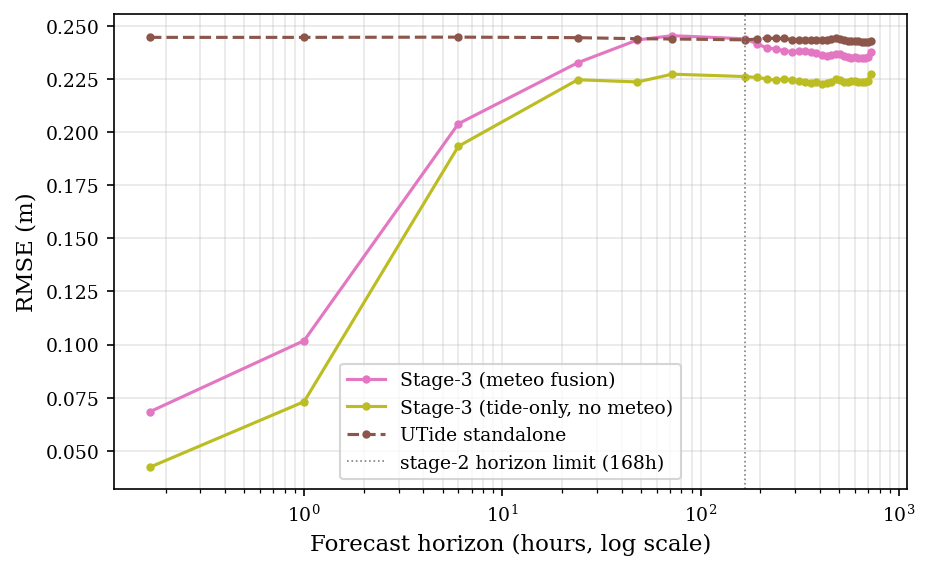


For scale: observed water level over the test set ranges roughly -1.32m to 1.83m ODN (mean +/- 1 std across horizons).
   10min: full model vs. tide-only RMSE: -61.7% (positive = adding meteo/river helped)
      1h: full model vs. tide-only RMSE: -39.3% (positive = adding meteo/river helped)
      6h: full model vs. tide-only RMSE: -5.5% (positive = adding meteo/river helped)
     24h: full model vs. tide-only RMSE: -3.6% (positive = adding meteo/river helped)
     48h: full model vs. tide-only RMSE: -8.8% (positive = adding meteo/river helped)
     72h: full model vs. tide-only RMSE: -8.0% (positive = adding meteo/river helped)
    168h: full model vs. tide-only RMSE: -7.8% (positive = adding meteo/river helped)


In [74]:
horizon_hours = np.array(HORIZON_STEPS) / 6.0  # steps are 10-min -> hours
rmse_pivot = metrics_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES]

fig = plt.figure(figsize=(10, 5))
for name in rmse_pivot.index:
    style = '--' if 'UTide' in name else '-'
    plt.plot(horizon_hours, rmse_pivot.loc[name], marker='o', markersize=3, linestyle=style, label=name,
              color=SERIES_COLOURS.get(name))
plt.axvline(168, color='grey', linewidth=0.8, linestyle=':', label='stage-2 horizon limit (168h)')
plt.xscale('log')
plt.xlabel('Forecast horizon (hours, log scale)')
plt.ylabel('RMSE (m)')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
save_fig(fig, 'stage3_rmse_vs_horizon_full')
plt.show()

print(f"\nFor scale: observed water level over the test set ranges roughly "
      f"{obs_mean_test.min() - obs_std_test.max():.2f}m to {obs_mean_test.max() + obs_std_test.max():.2f}m ODN "
      f"(mean +/- 1 std across horizons).")

# positive = full model's RMSE is lower than tide-only's -> meteo/river helped at that horizon
meteo_improvement_pct = 100 * (rmse_s3_tideonly - rmse_s3) / rmse_s3_tideonly
for h, pct in zip(HEADLINE_NAMES, meteo_improvement_pct[:len(HEADLINE_NAMES)]):
    print(f"  {h:>6s}: full model vs. tide-only RMSE: {pct:+.1f}% (positive = adding meteo/river helped)")

## 11. Save outputs to Google Drive

Both models' weights saved here, before the training-data ablation (s.12) and SHAP (s.13).

In [75]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'stage3_tidal_seq2seq_multi.pt')
torch.save({
    'model_state_dict': stage3_model.state_dict(),
    'config': {
        'enc_hidden_size': ENC_HIDDEN_SIZE, 'enc_num_layers': ENC_NUM_LAYERS,
        'meteo_hidden_size': METEO_HIDDEN_SIZE, 'meteo_lookback_hours': METEO_LOOKBACK_HOURS,
        'river_hidden_size': RIVER_HIDDEN_SIZE, 'river_lookback_days': RIVER_LOOKBACK_DAYS,
        'dec_hidden_size': DEC_HIDDEN_SIZE, 'dec_num_layers': DEC_NUM_LAYERS,
        'attn_dims': (ATTN_DIM_TIDE, ATTN_DIM_METEO, ATTN_DIM_RIVER),
        'lookback': LOOKBACK, 'horizons': HORIZONS, 'decoder_seq_steps': DECODER_SEQ_STEPS,
        'target_slice_in_decoder': [TARGET_SLICE_IN_DECODER.start, TARGET_SLICE_IN_DECODER.stop],
        'lr': LR_MULTI, 'weight_decay': WD_MULTI, 'batch_size': BATCH_MULTI,  # winner of s.9a's search
    },
    'scalers': {
        'tide_utide': {'mean': train_mean, 'std': train_std},
        'pressure': {'mean': pressure_mean, 'std': pressure_std},
        'u10': {'mean': u10_mean, 'std': u10_std},
        'v10': {'mean': v10_mean, 'std': v10_std},
        'rainfall': {'mean': rain_mean, 'std': rain_std},
        'discharge': {'mean': disc_mean, 'std': disc_std},
    },
}, checkpoint_path)
print(f"saved {checkpoint_path}")

tideonly_checkpoint_path = os.path.join(OUTPUT_DIR, 'stage3_tidal_seq2seq_tideonly.pt')
torch.save({
    'model_state_dict': stage3_tideonly_model.state_dict(),
    'config': {
        'enc_hidden_size': ENC_HIDDEN_SIZE, 'enc_num_layers': ENC_NUM_LAYERS,
        'dec_hidden_size': DEC_HIDDEN_SIZE, 'dec_num_layers': DEC_NUM_LAYERS,
        'attn_dim': ATTN_DIM_TIDE,
        'lookback': LOOKBACK, 'horizons': HORIZONS, 'decoder_seq_steps': DECODER_SEQ_STEPS,
        'target_slice_in_decoder': [TARGET_SLICE_IN_DECODER.start, TARGET_SLICE_IN_DECODER.stop],
        'lr': LR_TIDEONLY, 'weight_decay': WD_TIDEONLY, 'batch_size': BATCH_TIDEONLY,  # s.9a winner
    },
    'scalers': {'tide_utide': {'mean': train_mean, 'std': train_std}},
}, tideonly_checkpoint_path)
print(f"saved {tideonly_checkpoint_path}")

print(f"\nAll stage-3 outputs (so far) are under: {OUTPUT_DIR}")
import glob
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*'))):
    print(f"  {os.path.basename(p)}")


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_multi.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly.pt

All stage-3 outputs (so far) are under: /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs
  stage3_loss_curve.png
  stage3_lr_search_multi.csv
  stage3_lr_search_tideonly.csv
  stage3_metrics.csv
  stage3_reduced_training_data_metrics.csv
  stage3_reduced_training_rmse_vs_horizon.png
  stage3_reduced_training_utide_only_metrics.csv
  stage3_rmse_vs_horizon_full.png
  stage3_rmse_vs_training_years.png
  stage3_shap_branch_contributions.csv
  stage3_shap_branch_contributions.png
  stage3_shap_tide_lookback_heatmap.png
  stage3_shap_tide_lookback_importance.csv
  stage3_tidal_seq2seq_multi.pt
  stage3_tidal_seq2seq_multi_reduced_10yr.pt
  stage3_tidal_seq2seq_multi_reduced_3yr.pt
  stage3_tidal_seq2seq_multi_reduced_7yr.pt
  stage3_tidal_seq2seq_tideonly.pt
  sta

## 12. Training-data-volume ablation

Mirrors stage 2 section 13.3: train end fixed at 2018-01-01, only the training window start moves (2015/2011/2008 vs. the full 2004-2018). UTide refit per window; hyperparameters held fixed at the tide-only model's winning config, since here training-data volume is the one thing meant to vary. Only the tide-only model is retrained -- it outperformed the meteo-fusion model at s.10, so it's the one this ablation now tracks.

In [76]:
REDUCED_TRAIN_STARTS = {'3yr': '2015-01-01', '7yr': '2011-01-01', '10yr': '2008-01-01'}


def refit_utide_recon_ext(train_start, train_end):
    # same fit discipline as s.4, restricted to [train_start, train_end); reconstructed over
    # the same extended range so the padded decoder sequence (s.6/s.8c) stays computable.
    mask = (df['DateTime'] >= train_start) & (df['DateTime'] < train_end)
    fit_series = df.loc[mask, 'Observed_ODN'].copy()
    fit_series[df.loc[mask, 'is_flagged']] = np.nan
    coef_r = utide.solve(df.loc[mask, 'DateTime'], fit_series, lat=SITE_LAT, method='ols', conf_int='none')
    recon_r = utide.reconstruct(utide_index, coef_r, min_SNR=0, min_PE=0, verbose=False)
    return np.asarray(recon_r['h'], dtype=np.float32)


def prepare_reduced_scenario(name, train_start):
    recon_r = refit_utide_recon_ext(train_start, TRAIN_END)
    tr_df_r = df[(df['DateTime'] >= train_start) & (df['DateTime'] < TRAIN_END)].reset_index(drop=True)

    # val/test windows are rebuilt (not reused) because the decoder's UTide input -- and the
    # UTide-standalone comparator -- must reflect what a model trained only on this window
    # would actually have seen; only Y (the real observed target) is unaffected by the refit.
    Xtr, Xmtr, Xrtr, Ydtr, Ytr, Ftr, Ttr, Atr = build_windows_stage3(
        tr_df_r, LOOKBACK, HORIZON_STEPS, utide_full=recon_r, utide_start=UTIDE_START)
    Xva, Xmva, Xrva, Ydva, Yva, Fva, Tva, Ava = build_windows_stage3(
        val_df, LOOKBACK, HORIZON_STEPS, utide_full=recon_r, utide_start=UTIDE_START)
    Xte, Xmte, Xrte, Ydte, Yte, Fte, Tte, Ate = build_windows_stage3(
        test_df, LOOKBACK, HORIZON_STEPS, utide_full=recon_r, utide_start=UTIDE_START)

    Xtr, Xmtr, Xrtr, Ydtr, Ytr, Ftr = (Xtr[::TRAIN_STRIDE], Xmtr[::TRAIN_STRIDE], Xrtr[::TRAIN_STRIDE],
                                        Ydtr[::TRAIN_STRIDE], Ytr[::TRAIN_STRIDE], Ftr[::TRAIN_STRIDE])

    mean_, std_ = float(tr_df_r['Observed_ODN'].mean()), float(tr_df_r['Observed_ODN'].std())
    p_mean_, p_std_ = float(Xmtr[..., 0].mean()), float(Xmtr[..., 0].std())
    u_mean_, u_std_ = float(Xmtr[..., 1].mean()), float(Xmtr[..., 1].std())
    v_mean_, v_std_ = float(Xmtr[..., 2].mean()), float(Xmtr[..., 2].std())
    r_mean_, r_std_ = float(Xrtr[..., 0].mean()), float(Xrtr[..., 0].std())
    d_mean_, d_std_ = float(Xrtr[..., 1].mean()), float(Xrtr[..., 1].std())

    def sc_tide(a):
        return (a - mean_) / std_

    def sc_meteo(xm):
        out = xm.copy()
        out[..., 0] = (out[..., 0] - p_mean_) / p_std_
        out[..., 1] = (out[..., 1] - u_mean_) / u_std_
        out[..., 2] = (out[..., 2] - v_mean_) / v_std_
        return out

    def sc_river(xr):
        out = xr.copy()
        out[..., 0] = (out[..., 0] - r_mean_) / r_std_
        out[..., 1] = (out[..., 1] - d_mean_) / d_std_
        return out

    train_tensors_r = {'X': to_tensor(sc_tide(Xtr)), 'Xm': to_tensor(sc_meteo(Xmtr)), 'Xr': to_tensor(sc_river(Xrtr)),
                        'Ydec': to_tensor(sc_tide(Ydtr)), 'Y': to_tensor(sc_tide(Ytr)), 'Flag': to_tensor(Ftr, dtype=torch.bool)}
    val_tensors_r = {'X': to_tensor(sc_tide(Xva)), 'Xm': to_tensor(sc_meteo(Xmva)), 'Xr': to_tensor(sc_river(Xrva)),
                      'Ydec': to_tensor(sc_tide(Ydva)), 'Y': to_tensor(sc_tide(Yva)), 'Flag': to_tensor(Fva, dtype=torch.bool)}
    test_tensors_r = {'X': to_tensor(sc_tide(Xte)), 'Xm': to_tensor(sc_meteo(Xmte)), 'Xr': to_tensor(sc_river(Xrte)),
                       'Ydec': to_tensor(sc_tide(Ydte))}

    print(f"[{name}] train {tr_df_r.DateTime.min().date()} -> {tr_df_r.DateTime.max().date()} "
          f"({Xtr.shape[0]:,} windows, stride {TRAIN_STRIDE})  val {Xva.shape[0]:,}  test {Xte.shape[0]:,}")

    return {
        'name': name, 'mean': mean_, 'std': std_,
        'train_tensors': train_tensors_r, 'val_tensors': val_tensors_r, 'test_tensors': test_tensors_r,
        'Y_test': Yte, 'Flag_test': Fte, 'Ydec_test': Ydte[:, TARGET_SLICE_IN_DECODER],
    }


@torch.no_grad()
def compute_metrics_scaled(model, predict_fn, tensors, y_raw, flagged, mean_, std_, batch_size=4096):
    # same as compute_metrics, but takes the scaler explicitly -- each reduced scenario has
    # its own mean/std, fit only on the data that scenario was allowed to see.
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * std_ + mean_
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae


In [77]:
reduced_results = [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_s3_tideonly[j], 'mae_m': mae_s3_tideonly[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]
reduced_utide_only = [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_utide[j], 'mae_m': mae_utide[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]

stage3_reduced_tideonly_models = {}

for name, start in REDUCED_TRAIN_STARTS.items():
    n_years = int(name.replace('yr', ''))
    scen = prepare_reduced_scenario(name, start)

    rmse_u, mae_u = masked_rmse_mae(scen['Ydec_test'], scen['Y_test'], scen['Flag_test'])
    reduced_utide_only += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_u[j], 'mae_m': mae_u[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

    checkpoint_path_reduced = os.path.join(OUTPUT_DIR, f'stage3_tidal_seq2seq_tideonly_reduced_{name}.pt')

    def _train_reduced(m, scen=scen, name=name):
        return train_model(
            m, predict_stage3_tideonly, scen['train_tensors'], scen['val_tensors'],
            epochs=EPOCHS, batch_size=BATCH_TIDEONLY, lr=LR_TIDEONLY, patience=PATIENCE,
            weight_decay=WD_TIDEONLY, label=f'stage3-tideonly-{name}',  # held fixed at s.9a's winner -- see markdown above
        )

    set_seed()
    m = TidalSeq2SeqTideOnly().to(device)
    m, _ = load_or_train(m, checkpoint_path_reduced, _train_reduced, label=f'stage3-tideonly-{name}')
    torch.save({'model_state_dict': m.state_dict(),
                'scaler': {'mean': scen['mean'], 'std': scen['std']},
                'config': {'train_years': n_years, 'train_start': start}}, checkpoint_path_reduced)
    print(f"saved {checkpoint_path_reduced}")
    stage3_reduced_tideonly_models[name] = m

    rmse_r, mae_r = compute_metrics_scaled(
        m, predict_stage3_tideonly, scen['test_tensors'], scen['Y_test'], scen['Flag_test'], scen['mean'], scen['std'])
    reduced_results += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_r[j], 'mae_m': mae_r[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

reduced_df = pd.DataFrame(reduced_results)
reduced_metrics_path = os.path.join(OUTPUT_DIR, 'stage3_reduced_training_data_metrics.csv')
reduced_df.to_csv(reduced_metrics_path, index=False)
print(f"saved {reduced_metrics_path}")

utide_only_df = pd.DataFrame(reduced_utide_only)
utide_only_metrics_path = os.path.join(OUTPUT_DIR, 'stage3_reduced_training_utide_only_metrics.csv')
utide_only_df.to_csv(utide_only_metrics_path, index=False)
print(f"saved {utide_only_metrics_path}")

train_years_order = reduced_df.drop_duplicates('model').set_index('model')['train_years'].sort_values()
reduced_pivot = reduced_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].loc[train_years_order.index]

solve: matrix prep ... solution ... done.
[3yr] train 2015-01-01 -> 2017-12-31 (44,119 windows, stride 3)  val 153,409  test 169,821
[stage3-tideonly-3yr] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly_reduced_3yr.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly_reduced_3yr.pt
solve: matrix prep ... solution ... done.
[7yr] train 2011-01-01 -> 2017-12-31 (98,075 windows, stride 3)  val 153,409  test 169,821
[stage3-tideonly-7yr] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly_reduced_7yr.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_tidal_seq2seq_tideonly_reduced_7yr.pt
solve: matrix prep ... solution ... done.
[10yr] train 2008-01-01 -> 2017-12-31 (134,785 windows, stride 3)  val 153,409  test 169,821
[stage3-tideonly-10yr] epoch 001  train_loss=0.0806

In [78]:
print("RMSE (m) by training-data window, headline 7 horizons:")
with_observed_row(reduced_pivot[HEADLINE_NAMES], HEADLINE_NAMES).round(4)


RMSE (m) by training-data window, headline 7 horizons:


,10min,1h,6h,24h,48h,72h,168h
"Observed (mean, m)",0.2528,0.2524,0.2527,0.2532,0.2539,0.2538,0.2528
3yr,0.0345,0.0857,0.2368,0.2392,0.2437,0.2480,0.2429
7yr,0.0365,0.0783,0.2212,0.2364,0.2398,0.2452,0.2403
10yr,0.0340,0.0747,0.2170,0.2339,0.2334,0.2358,0.2340
14yr (full),0.0423,0.0731,0.1933,0.2246,0.2235,0.2272,0.2261


saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_reduced_training_rmse_vs_horizon.pdf


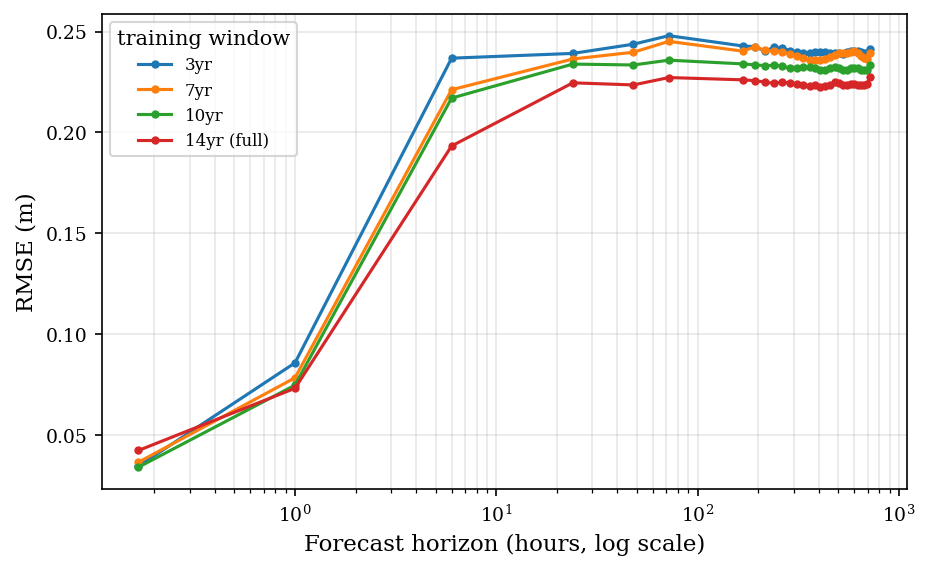

saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_rmse_vs_training_years.pdf


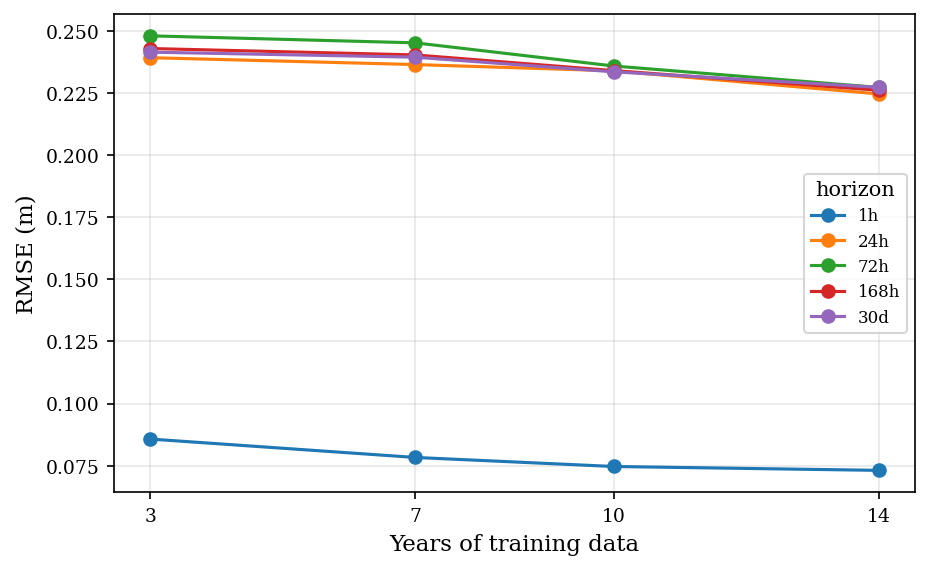

In [79]:
fig = plt.figure(figsize=(10, 5))
for name in reduced_pivot.index:
    plt.plot(horizon_hours, reduced_pivot.loc[name], marker='o', markersize=3, label=name)
plt.xscale('log')
plt.xlabel('Forecast horizon (hours, log scale)')
plt.ylabel('RMSE (m)')
plt.legend(title='training window', fontsize=8)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
save_fig(fig, 'stage3_reduced_training_rmse_vs_horizon')
plt.show()

fixed_horizons_check = [h for h in ['1h', '24h', '72h', '168h', '30d'] if h in HORIZON_NAMES]
fig = plt.figure(figsize=(8, 5))
for hname in fixed_horizons_check:
    ys = [reduced_pivot.loc[name, hname] for name in train_years_order.index]
    plt.plot(train_years_order.values, ys, marker='o', label=hname)
plt.xlabel('Years of training data')
plt.ylabel('RMSE (m)')
plt.legend(title='horizon', fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(sorted(train_years_order.unique()))
save_fig(fig, 'stage3_rmse_vs_training_years')
plt.show()

## 13. Interpretability: SHAP

`shap.GradientExplainer` on the full model, over a representative subset of horizons (10min, 6h, 24h, 168h, 14d, 30d). Raw per-scalar SHAP values are summed into branch/variable-level contributions.

cuDNN's fused RNN kernel needs training-mode state for its backward pass, which SHAP's `.backward()` call breaks in `.eval()` mode (`RuntimeError: cudnn RNN backward can only be called in training mode`). Fixed by disabling cuDNN's fused RNN kernel for this block (`torch.backends.cudnn.flags(enabled=False)`) rather than switching the model into `.train()` mode. Not verified against a real GPU locally.

Placed last since everything else (both models, evaluation, checkpoints, the training-data ablation) has already run and saved by this point.

In [80]:
class HorizonWrapper(nn.Module):
    # SHAP explains one fixed-size output per call; this selects a single horizon
    # out of the model's (B, 30) prediction so GradientExplainer sees a (B, 1) output.
    def __init__(self, base_model, horizon_idx):
        super().__init__()
        self.base_model = base_model
        self.horizon_idx = horizon_idx

    def forward(self, x_tide, x_meteo, x_river, x_utide):
        preds, _ = self.base_model(x_tide, x_meteo, x_river, x_utide)
        return preds[:, self.horizon_idx:self.horizon_idx + 1]


SHAP_HORIZONS = ['10min', '6h', '24h', '168h', '14d', '30d']
SHAP_BACKGROUND_N = 150
SHAP_EXPLAIN_N = 300

set_seed()
bg_idx = np.random.choice(X_train_t.shape[0], size=SHAP_BACKGROUND_N, replace=False)
explain_idx = np.random.choice(X_test_t.shape[0], size=SHAP_EXPLAIN_N, replace=False)

shap_background = [X_train_t[bg_idx], Xm_train_t[bg_idx], Xr_train_t[bg_idx], Ydec_train_t[bg_idx]]
shap_explain_inputs = [X_test_t[explain_idx], Xm_test_t[explain_idx], Xr_test_t[explain_idx], Ydec_test_t[explain_idx]]

# cuDNN's fused RNN kernel only retains backward-pass state when the forward call runs in
# training mode, so GradientExplainer's backward() through the LSTMs fails on a .eval()-mode
# model (see the markdown above for the full explanation). Keeping the model in genuine
# eval() mode -- correct, since SHAP is explaining a trained model, not training one -- and
# disabling cuDNN's fused kernel just for this block routes PyTorch to the generic RNN
# backward implementation instead, which has no such restriction.
stage3_model.eval()
shap_rows = []
tide_lookback_importance = {}
with torch.backends.cudnn.flags(enabled=False):
    for hname in SHAP_HORIZONS:
        j = HORIZON_NAMES.index(hname)
        wrapped = HorizonWrapper(stage3_model, horizon_idx=j)
        explainer = shap.GradientExplainer(wrapped, shap_background)
        sv_tide, sv_meteo, sv_river, sv_utide = explainer.shap_values(shap_explain_inputs)
        sv_tide, sv_meteo, sv_river, sv_utide = [np.abs(s).squeeze(-1) for s in (sv_tide, sv_meteo, sv_river, sv_utide)]

        shap_rows.append({
            'horizon': hname,
            'tide_history': sv_tide.sum(axis=1).mean(),
            'pressure': sv_meteo[..., 0].sum(axis=1).mean(),
            'wind_u10': sv_meteo[..., 1].sum(axis=1).mean(),
            'wind_v10': sv_meteo[..., 2].sum(axis=1).mean(),
            'rainfall': sv_river[..., 0].sum(axis=1).mean(),
            'discharge': sv_river[..., 1].sum(axis=1).mean(),
            'river_availability_flags': sv_river[..., 2:4].sum(axis=(1, 2)).mean(),
            'utide_decoder': sv_utide.sum(axis=1).mean(),
        })
        tide_lookback_importance[hname] = sv_tide.mean(axis=0)  # (96,)
        print(f"SHAP done for horizon {hname}")

shap_df = pd.DataFrame(shap_rows).set_index('horizon').loc[SHAP_HORIZONS]
shap_summary_path = os.path.join(OUTPUT_DIR, 'stage3_shap_branch_contributions.csv')
shap_df.to_csv(shap_summary_path)
print(f"saved {shap_summary_path}")
shap_df.round(4)


SHAP done for horizon 10min
SHAP done for horizon 6h
SHAP done for horizon 24h
SHAP done for horizon 168h
SHAP done for horizon 14d
SHAP done for horizon 30d
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_shap_branch_contributions.csv


,tide_history,pressure,wind_u10,wind_v10,rainfall,discharge,river_availability_flags,utide_decoder
horizon,,,,,,,,
10min,1.3895,0.0195,0.0191,0.0216,0.0232,0.0247,0.0082,0.9809
6h,0.4666,0.0620,0.0459,0.0812,0.0303,0.0266,0.0081,1.0868
24h,0.1405,0.0714,0.0318,0.0438,0.0361,0.0296,0.0088,1.0102
168h,0.1025,0.0200,0.0154,0.0172,0.0324,0.0312,0.0070,0.9471
14d,0.0828,0.0131,0.0110,0.0091,0.0342,0.0366,0.0072,1.0615
30d,0.1076,0.0145,0.0155,0.0140,0.0344,0.0406,0.0078,1.0876


saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_branch_contributions.pdf


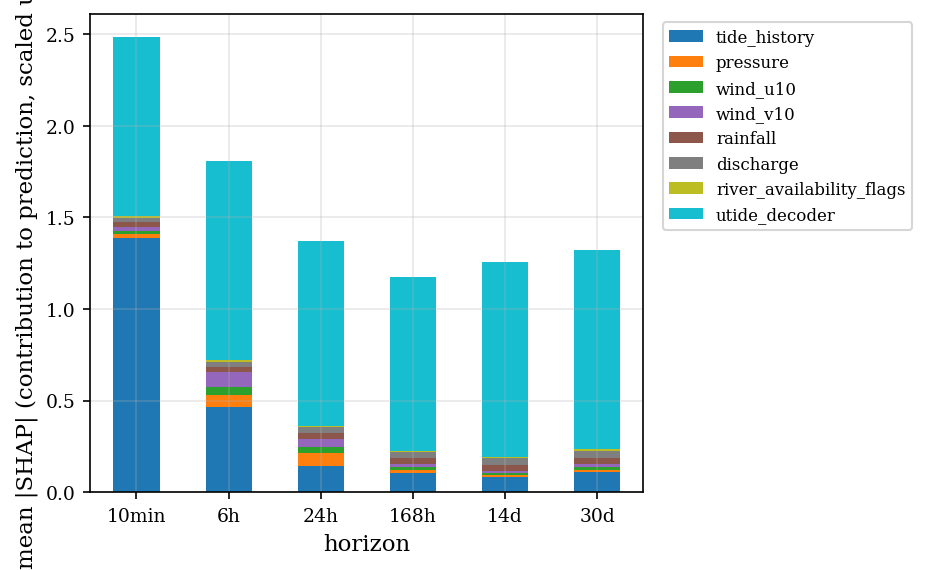

In [81]:
ax = shap_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
ax.set_ylabel('mean |SHAP| (contribution to prediction, scaled units)')
ax.set_xlabel('horizon')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(ax.figure, 'stage3_shap_branch_contributions')
plt.show()

saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_tide_lookback_heatmap.pdf


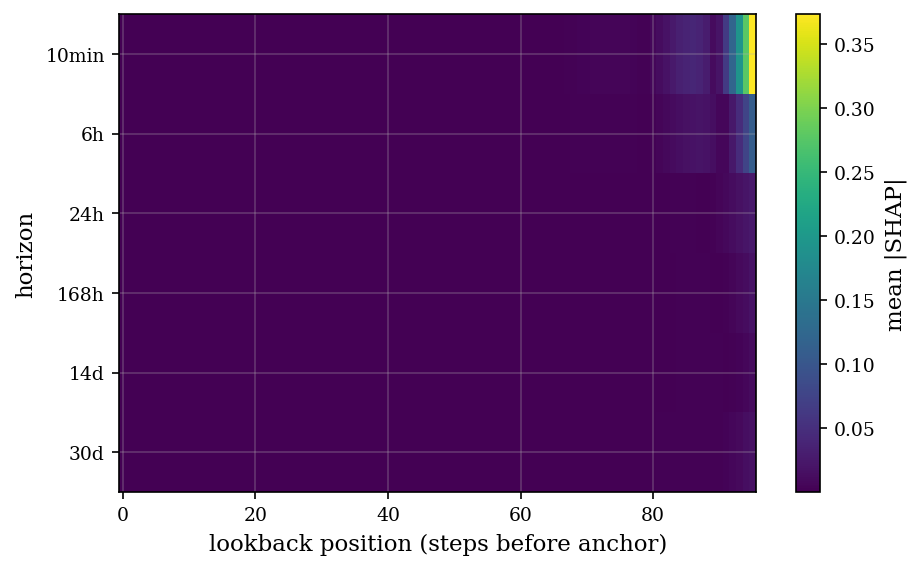

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage3_outputs/stage3_shap_tide_lookback_importance.csv


In [82]:
lookback_matrix = np.stack([tide_lookback_importance[h] for h in SHAP_HORIZONS])  # (n_shap_horizons, 96)

fig = plt.figure(figsize=(12, 4))
plt.imshow(lookback_matrix, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(label='mean |SHAP|')
plt.yticks(range(len(SHAP_HORIZONS)), SHAP_HORIZONS)
plt.xlabel('lookback position (steps before anchor)')
plt.ylabel('horizon')
plt.tight_layout()
save_fig(fig, 'stage3_shap_tide_lookback_heatmap')
plt.show()

shap_summary_path2 = os.path.join(OUTPUT_DIR, 'stage3_shap_tide_lookback_importance.csv')
pd.DataFrame(lookback_matrix, index=SHAP_HORIZONS).to_csv(shap_summary_path2)
print(f"saved {shap_summary_path2}")

### 13.1 Additional SHAP views

The stacked bar above shrinks in total height as horizon grows, which confounds any comparison of *composition* across horizons -- and the heatmap shares one colour scale across rows that differ by roughly an order of magnitude in peak size (10min vs the longer horizons), which washes out everything but the 10min row. The cells below re-derive comparable views from the two CSVs already saved above -- no re-running of `GradientExplainer`.

saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_branch_contributions_pct.pdf


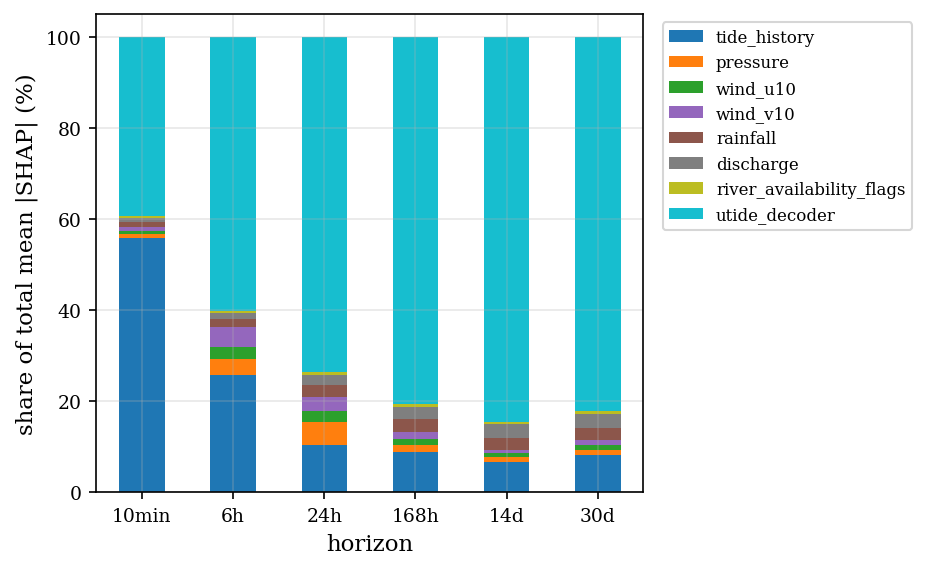

In [83]:
shap_pct = shap_df.div(shap_df.sum(axis=1), axis=0) * 100
ax = shap_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
ax.set_ylabel('share of total mean |SHAP| (%)')
ax.set_xlabel('horizon')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(ax.figure, 'stage3_shap_branch_contributions_pct')
plt.show()

saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_covariates_only.pdf


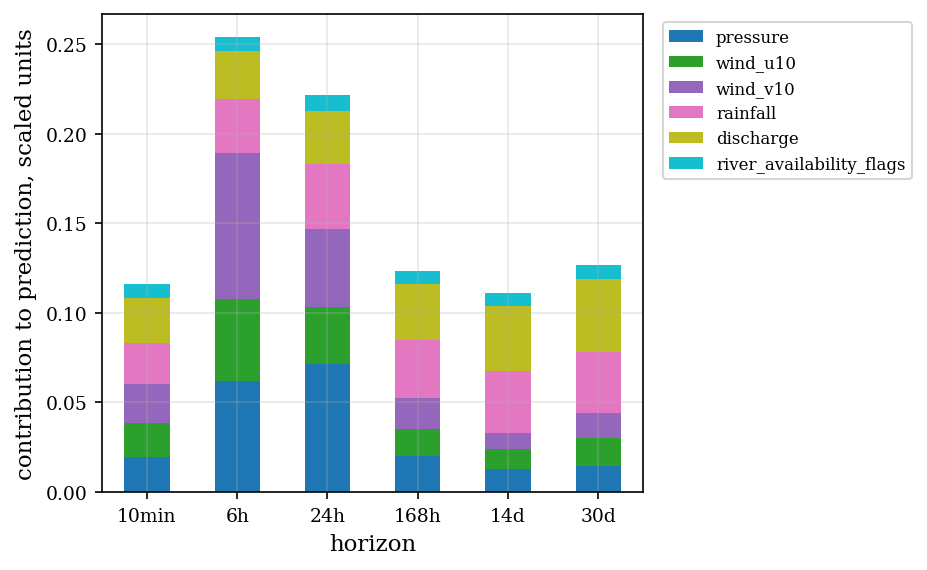

In [89]:
covariate_cols = ['pressure', 'wind_u10', 'wind_v10', 'rainfall', 'discharge', 'river_availability_flags']
ax = shap_df[covariate_cols].plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
ax.set_ylabel('contribution to prediction, scaled units')
ax.set_xlabel('horizon')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(ax.figure, 'stage3_shap_covariates_only')
plt.show()

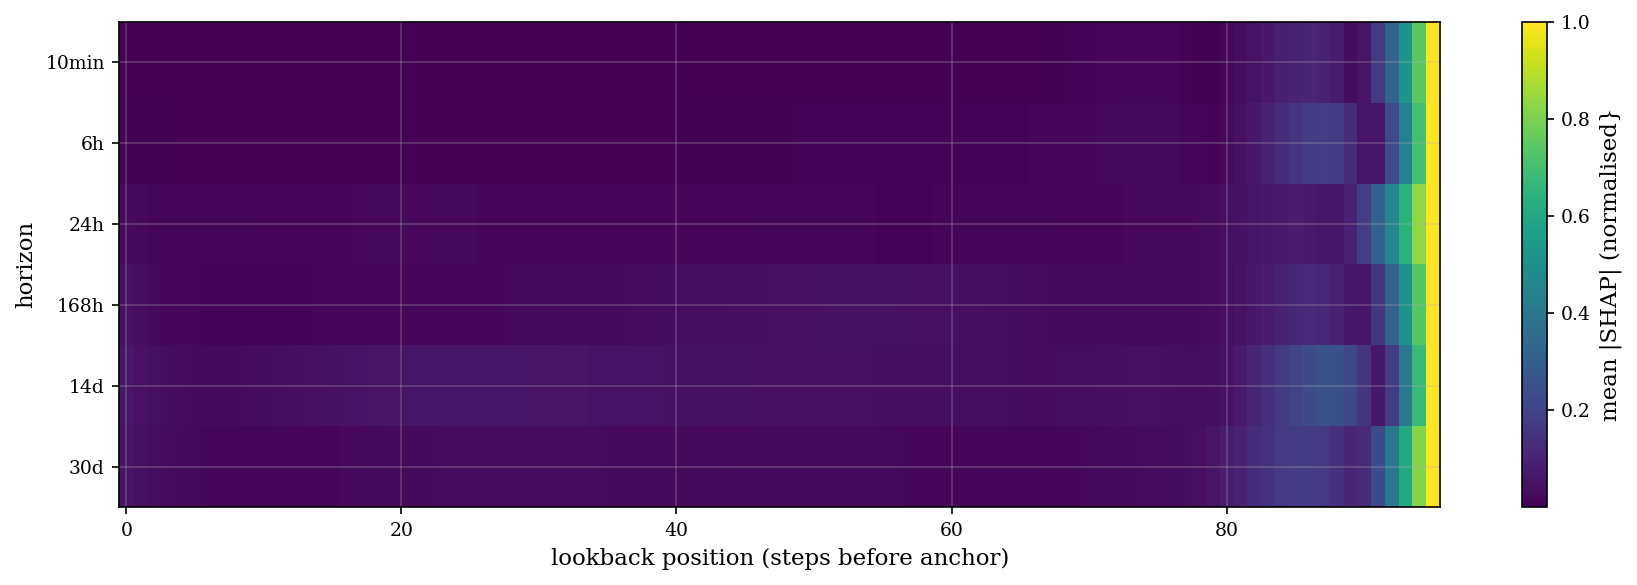

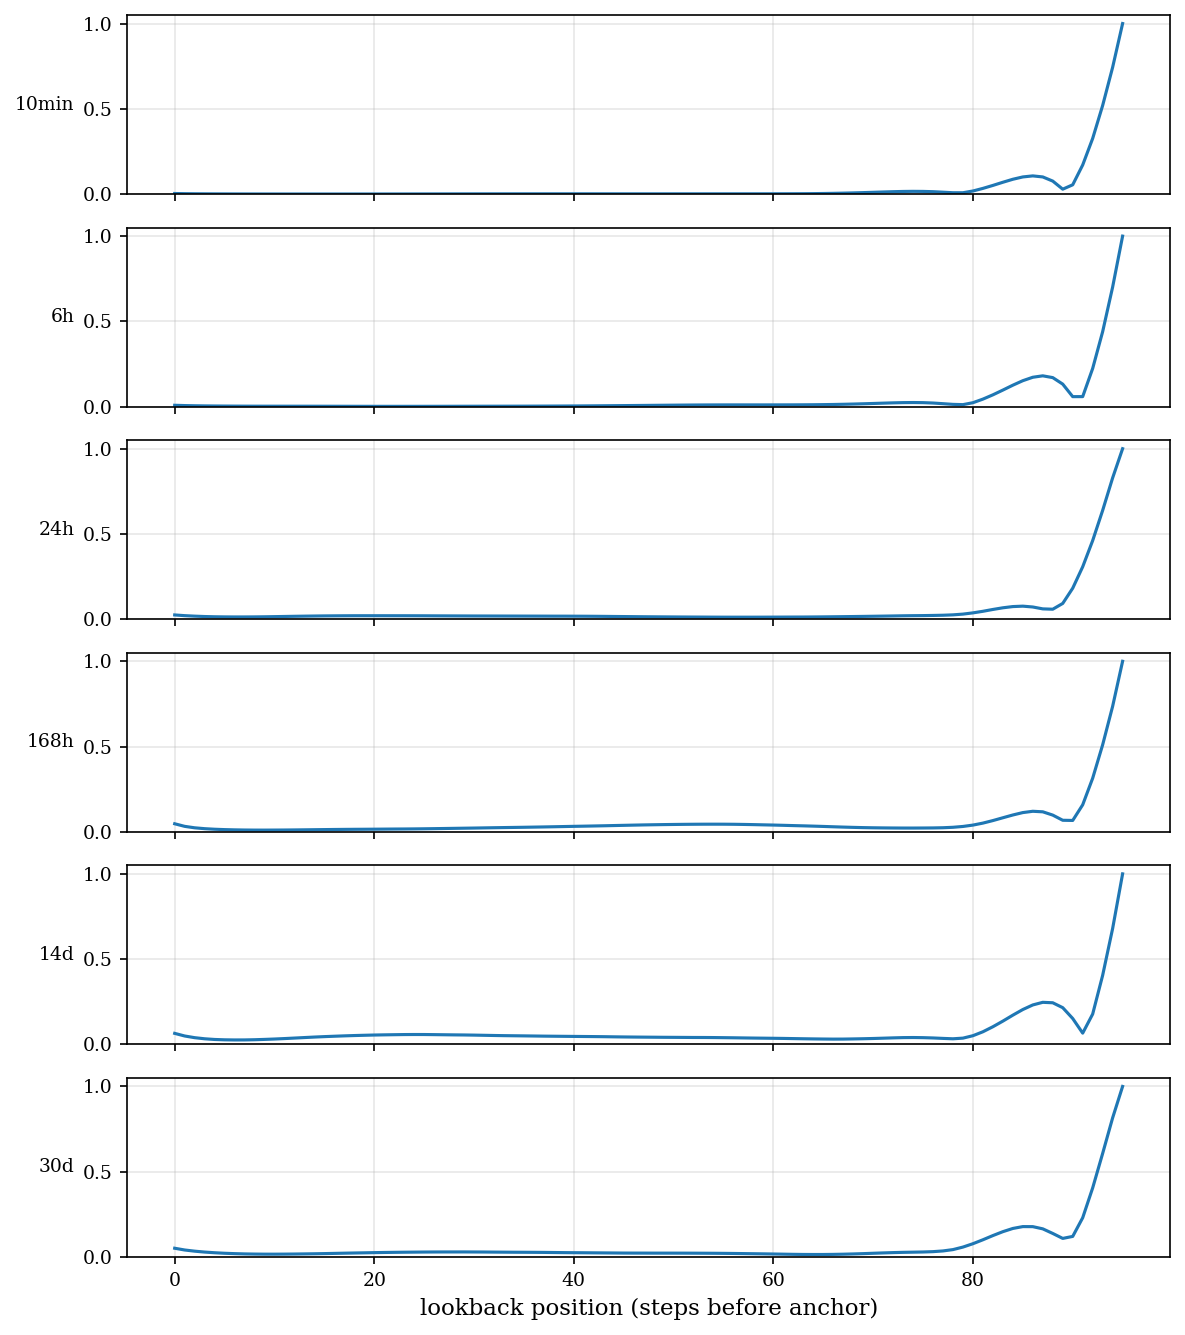

saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_tide_lookback_normalized.pdf


'/content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_tide_lookback_normalized.pdf'

In [90]:
row_normed = lookback_matrix / lookback_matrix.max(axis=1, keepdims=True)

# attempt 1: same heatmap as above, now row-normalised so all six horizons share one 0-1
# scale instead of being crushed under the 10min row's peak
fig_heat = plt.figure(figsize=(12, 4))
plt.imshow(row_normed, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(label="mean |SHAP| (normalised}") # normalised to each horizon's peak, so all horizons share the same 0-1 scale)
plt.yticks(range(len(SHAP_HORIZONS)), SHAP_HORIZONS)
plt.xlabel('lookback position (steps before anchor)')
plt.ylabel('horizon')
plt.tight_layout()

# attempt 2: six small-multiple line plots -- with only six rows, a shared-scale heatmap
# still can't show the actual curve shape as precisely as a line can
fig_lines, axes = plt.subplots(len(SHAP_HORIZONS), 1, figsize=(8, 9), sharex=True)
for ax, hname in zip(axes, SHAP_HORIZONS):
    ax.plot(row_normed[SHAP_HORIZONS.index(hname)], color='#1f77b4')
    ax.set_ylabel(hname, rotation=0, ha='right', va='center', fontsize=9)
    ax.set_ylim(0, 1.05)
axes[-1].set_xlabel('lookback position (steps before anchor)')
plt.tight_layout()
plt.show()

# the line plots read more clearly here -- every horizon shares the same shape (importance
# near zero through most of the lookback window, a modest rise and slight dip in the last
# ~15 steps, then a sharp spike at the anchor itself) far more precisely than colour can at
# just six rows, so that's the one saved
save_fig(fig_lines, 'stage3_shap_tide_lookback_normalized')

### 13.2 SHAP vs. attention weights

One more check: does the decoder's own tide-branch attention (learned during training) agree with what SHAP independently attributes to the same lookback positions? A single forward pass (no gradients) reads off the attention weights the trained model already computes; SHAP's tide-lookback importance is reused from s.13/13.1 above.

w_tide shape: (300, 30, 96)
saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage3_shap_vs_attention.pdf


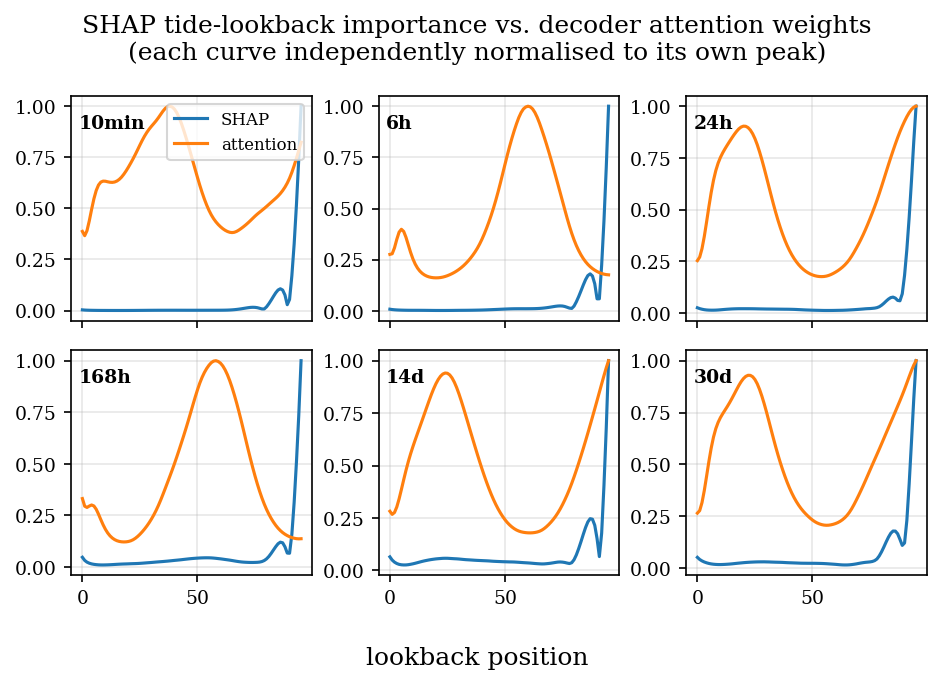

In [86]:
stage3_model.eval()
with torch.no_grad():
    _, (w_tide, w_meteo, w_river) = stage3_model(*shap_explain_inputs)
w_tide = w_tide.cpu().numpy()  # (N_explain, 30, 96)
print(f"w_tide shape: {w_tide.shape}")

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, hname in zip(axes.flat, SHAP_HORIZONS):
    shap_curve = tide_lookback_importance[hname]
    shap_curve = shap_curve / shap_curve.max()
    attn_curve = w_tide[:, HORIZON_NAMES.index(hname), :].mean(axis=0)
    attn_curve = attn_curve / attn_curve.max()

    ax.plot(shap_curve, label='SHAP')
    ax.plot(attn_curve, label='attention')
    ax.text(0.03, 0.92, hname, transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

axes[0, 0].legend(fontsize=8, loc='upper right')
fig.supxlabel('lookback position')
fig.suptitle('SHAP tide-lookback importance vs. decoder attention weights\n'
             '(each curve independently normalised to its own peak)')
plt.tight_layout()
save_fig(fig, 'stage3_shap_vs_attention', width_in=6.3, height_in=4.5)
plt.show()

In [87]:
print("Covariate share of total mean |SHAP| (#2), largest to smallest per horizon:")
for hname in SHAP_HORIZONS:
    row = shap_df.loc[hname, covariate_cols]
    top = row.idxmax()
    print(f"  {hname:>6s}: {row.sum():.4f} total covariate |SHAP| -- largest single covariate: "
          f"{top} ({row[top]:.4f}, {100 * row[top] / row.sum():.0f}% of the covariate share)")

print()
print("SHAP vs. attention agreement (#4), by horizon (Pearson correlation of the two "
      "normalised lookback curves):")
for hname in SHAP_HORIZONS:
    shap_curve = tide_lookback_importance[hname] / tide_lookback_importance[hname].max()
    attn_curve = w_tide[:, HORIZON_NAMES.index(hname), :].mean(axis=0)
    attn_curve = attn_curve / attn_curve.max()
    corr = np.corrcoef(shap_curve, attn_curve)[0, 1]
    verdict = 'agree' if corr > 0.5 else ('diverge' if corr < 0.0 else 'partially agree')
    print(f"  {hname:>6s}: r={corr:+.3f} -- {verdict}")

Covariate share of total mean |SHAP| (#2), largest to smallest per horizon:
   10min: 0.1162 total covariate |SHAP| -- largest single covariate: discharge (0.0247, 21% of the covariate share)
      6h: 0.2541 total covariate |SHAP| -- largest single covariate: wind_v10 (0.0812, 32% of the covariate share)
     24h: 0.2215 total covariate |SHAP| -- largest single covariate: pressure (0.0714, 32% of the covariate share)
    168h: 0.1233 total covariate |SHAP| -- largest single covariate: rainfall (0.0324, 26% of the covariate share)
     14d: 0.1112 total covariate |SHAP| -- largest single covariate: discharge (0.0366, 33% of the covariate share)
     30d: 0.1269 total covariate |SHAP| -- largest single covariate: discharge (0.0406, 32% of the covariate share)

SHAP vs. attention agreement (#4), by horizon (Pearson correlation of the two normalised lookback curves):
   10min: r=+0.118 -- partially agree
      6h: r=-0.211 -- diverge
     24h: r=+0.418 -- partially agree
    168h: r=-0.18